# Implementación de Modelos

In [4]:
# Importamos librerias a utilizar
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.stats import norm
from statsmodels.stats.diagnostic import acorr_ljungbox
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from statsmodels.tsa.stattools import bds
# Suavización exponencial
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.holtwinters import SimpleExpSmoothing 
# Arima
import statsmodels.tsa.api as smtsa
from statsmodels.tsa.arima.model import ARIMA
# Garch
from arch import arch_model
import statsmodels.api as sm
import seaborn as sns
# Machine Learning Models
import datetime
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow import keras
from keras.layers import Dense, Input, Dropout, SimpleRNN, Bidirectional, LSTM, Attention, Permute, Multiply
from keras.optimizers import SGD
from keras.models import Model
from keras.models import load_model
from keras.callbacks import ModelCheckpoint
import os
import re
from sklearn.metrics import mean_absolute_error
from joblib import dump, load

In [6]:
# importamos datos
filename = 'C:/Users/luis_/Desktop\MaestriaEstadisticaAplicada/_7SeriesDeTiempo/Proyectos_python/datos_proyecto/datos_velocidad_viento.xlsx'
data = pd.read_excel(filename)

In [7]:
# Haciendo que el index sean las mismas fechas
data.index = data['FechaObservacion']

In [8]:
# Dividiendo datos en conjunto de entrenamiento, validación y prueba.
train_data = data[:-576]
validation_data = data[len(train_data):len(train_data)+288]
test_data = data[len(train_data)+288:]

In [9]:
# Definiendo la función para calcular MAPE, MAE, MSE y RMSE
def forecast_accuracy(forecast, actual, str_name):
    
    mape = np.mean(np.abs(forecast - actual)/np.abs(actual)) # MAPE
    mae = np.mean(np.abs(forecast - actual))                 # MAE
    rmse = np.mean((forecast - actual)**2)**.5               # RMSE
    mse = np.mean((forecast - actual)**2)                    # MSE
    
    df_acc = pd.DataFrame({'MAE': [mae],
                           'MAPE': [mape],
                           'MSE': [mse],
                           'RMSE': [rmse]},
                          index=[str_name])
    
    return df_acc

## 1. Suavización exponencial de primer orden

### Selección de Modelo

In [10]:
# Función para realizar la suavización exponencial de primer orden
def firstsmooth(y, lambda_, start=None):
    ytilde = y.copy()
    if start is None:
        start = y[0]
    ytilde[0] = lambda_ * y[0] + (1 - lambda_) * start
    for i in range(1, len(y)):
        ytilde[i] = lambda_ * y[i] + (1 - lambda_) * ytilde[i - 1]
    return ytilde

In [11]:
# Función para realizar el forecast rolling
def firstsmooth_rolling(history, test, alpha):
    
    predictions = list()
    for t in range(len(test)):
        model = firstsmooth(history, alpha)
        yhat = model[-2]
        predictions.append(yhat)
        obs = test[t]
        history.append(obs)
        
    return predictions

In [12]:
# Se crea array de valores de lambda
lambda_values = np.arange(0.1, 1.0, 0.1)
mse_values = {}

In [ ]:
# Bucle para evaluar cada lambda, calculando el MSE
for lambda_v in lambda_values:
    
    forecast = firstsmooth_rolling(train_data['ValorObservado'][-1008:].tolist(), validation_data['ValorObservado'].tolist(), lambda_v)

    mse = forecast_accuracy(np.array(forecast), np.array(validation_data['ValorObservado']), "Value")['MSE'][0]
    mse_values[lambda_v] = mse

C:\Users\luis_\AppData\Local\Temp\ipykernel_12292\91380040.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  mse = forecast_accuracy(np.array(forecast), np.array(validation_data['ValorObservado']), "Value")['MSE'][0]


In [13]:
# Modelo seleccionado, lambda = 0.5
se1_hat = firstsmooth(train_data['ValorObservado'][-1008:], 0.5)

C:\Users\luis_\AppData\Local\Temp\ipykernel_20232\2702593709.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  start = y[0]
C:\Users\luis_\AppData\Local\Temp\ipykernel_20232\2702593709.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ytilde[0] = lambda_ * y[0] + (1 - lambda_) * start
C:\Users\luis_\AppData\Local\Temp\ipykernel_20232\2702593709.py:6: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ytilde[0] = lambda_ * y[0] +

### Gráfica de diagnóstico

In [14]:
# Residuales de modelo seleccionado
residuals_firstsmooth = train_data['ValorObservado'][-1008:] - se1_hat

c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


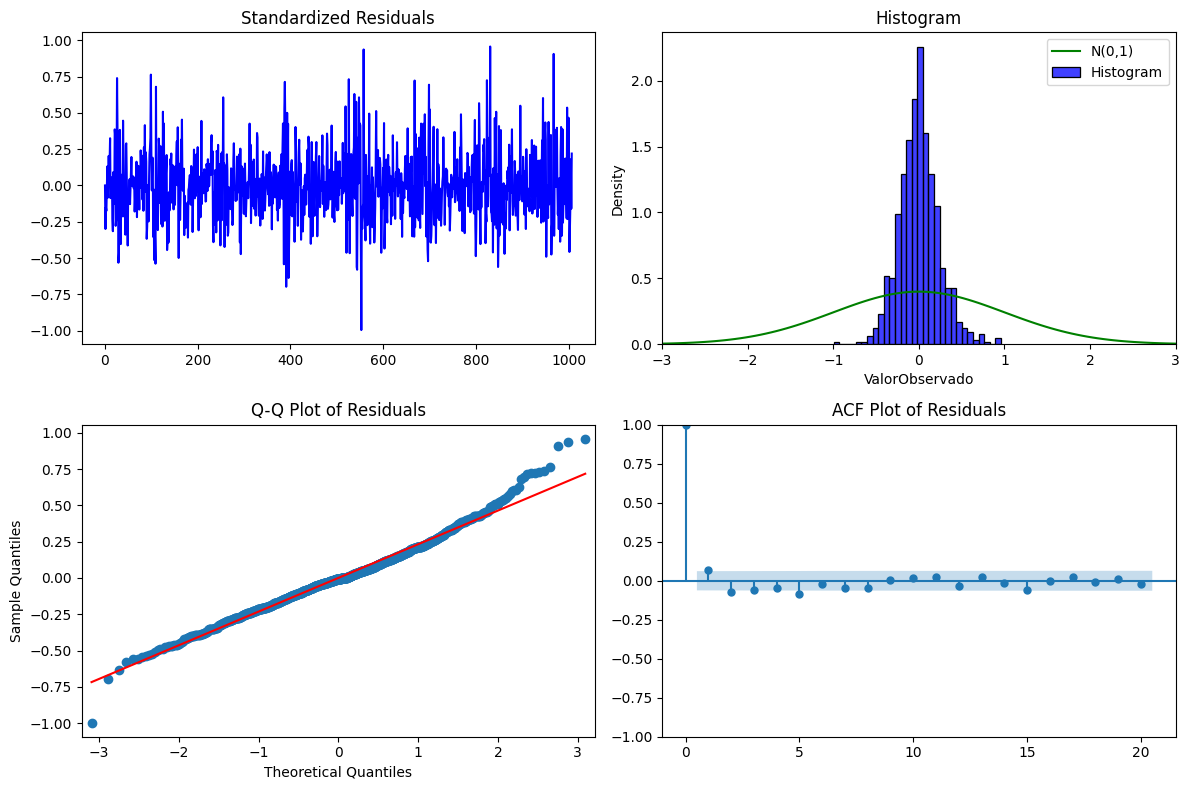

In [15]:
# Se crea gráfica de diagnóstico
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Plot 1: Standardized Residuals
axes[0, 0].plot(range(len(residuals_firstsmooth)),residuals_firstsmooth, color="blue")
axes[0, 0].set_title("Standardized Residuals")

# Plot 2: Histogram & KDE
sns.histplot(residuals_firstsmooth, stat="density", bins=30, kde=False, ax=axes[0, 1], color="blue", label = "Histogram")
axes[0, 1].set_xlim(-3, 3)
xmin, xmax = axes[0, 1].get_xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, 0, 1)  # Normal distribution N(0,1)
axes[0, 1].plot(x, p, 'g-', label = "N(0,1)")
axes[0, 1].set_title("Histogram")
axes[0, 1].legend()

# Plot 3: Q-Q Plot
sm.qqplot(residuals_firstsmooth, line="s", ax=axes[1, 0])
axes[1, 0].set_title("Q-Q Plot of Residuals")

# Plot 4: ACF
sm.graphics.tsa.plot_acf(residuals_firstsmooth, lags=20, ax=axes[1, 1])
axes[1, 1].set_title("ACF Plot of Residuals")

plt.tight_layout()
plt.show()

### Forecast

In [16]:
# Se calculan los valores predichos del conjunto de validación
yhat_expsmoth1 = firstsmooth_rolling(train_data['ValorObservado'][-1008:].tolist(), validation_data['ValorObservado'].tolist(), 0.5)

In [17]:
# Se calcula el error de predicción del conjunto de validación
forecast_accuracy( np.array(yhat_expsmoth1),np.array(validation_data['ValorObservado']), "Value")

,MAE,MAPE,MSE,RMSE
Value,0.480067,0.36742,0.450426,0.671138


In [18]:
# Se calculan los valores predichos del conjunto de test
yhat_expsmoth1_test = firstsmooth_rolling(train_data['ValorObservado'][-1008:].tolist(), test_data['ValorObservado'].tolist(), 0.5)

In [19]:
# Se calcula el error de predicción del conjunto de test
forecast_accuracy( np.array(yhat_expsmoth1_test), np.array(test_data['ValorObservado']), "Value")

,MAE,MAPE,MSE,RMSE
Value,0.441101,0.359027,0.368889,0.607362


### Forecast Plot

In [20]:
# Se calculan los residuales del conjunto de test
residuals_firstsmooth_test = test_data['ValorObservado'] - yhat_expsmoth1_test

In [21]:
# Se hace la prueba de Ljung-Box
lb_test = acorr_ljungbox(residuals_firstsmooth_test, lags=[144], return_df=True)
print(lb_test)

        lb_stat  lb_pvalue
144  234.818856   0.000003


In [26]:
# Prueba de BDS (Brock-Dechert-Scheinkman)
bds_stat, bds_p_value = bds(residuals_firstsmooth_test, max_dim=2, epsilon=None, distance=1.5)
print(f"BDS Statistic: {bds_stat}")
print(f"BDS p-value: {bds_p_value}")

BDS Statistic: 6.167399772289959
BDS p-value: 6.942208757636936e-10


c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a fu

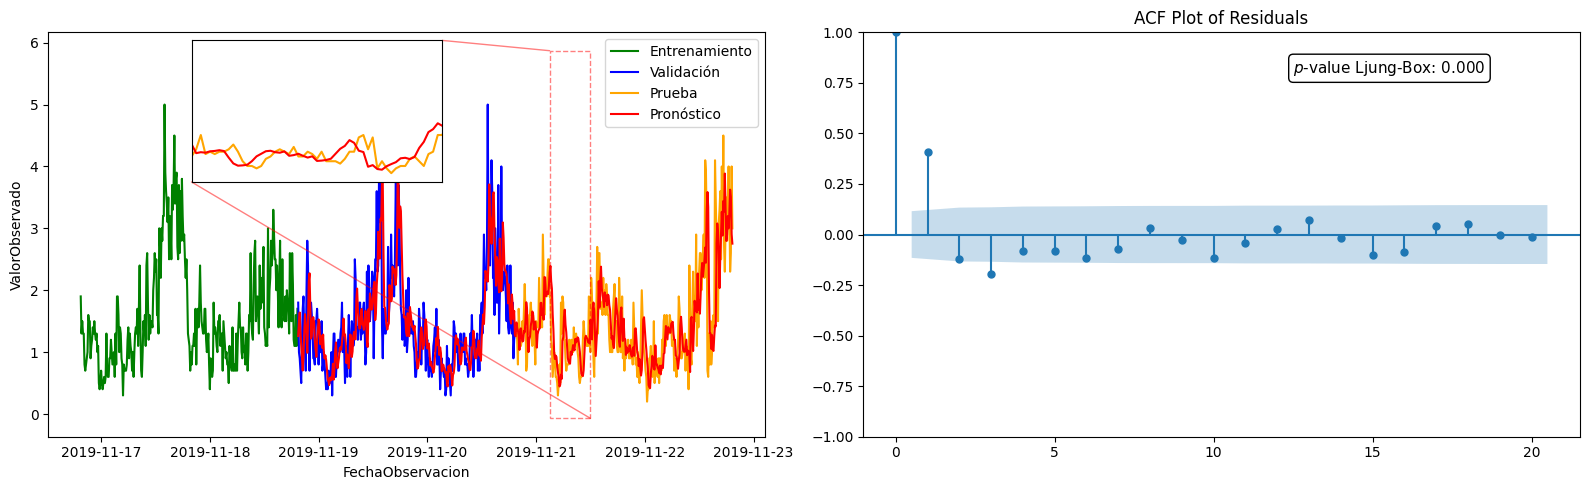

In [27]:
# Gráfica de valores observados vs predicciones
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = sns.lineplot(x=train_data['FechaObservacion'][-288:], y=train_data['ValorObservado'][-288:], label="Entrenamiento", color='g', ax=axes[0])
sns.lineplot(x=validation_data['FechaObservacion'], y=validation_data['ValorObservado'], label="Validación", color='b', ax=axes[0])
sns.lineplot(x=test_data['FechaObservacion'], y=test_data['ValorObservado'], label="Prueba", color='orange', ax=axes[0])
sns.lineplot(x=validation_data['FechaObservacion'], y=yhat_expsmoth1, label="Pronóstico", color='r', ax=axes[0])
sns.lineplot(x=test_data['FechaObservacion'], y=yhat_expsmoth1_test, color='r', ax=axes[0])

# Se añade gráfica ampliada
#  Se define la posición y tamaño ( [x, y, width, height] cada valor esta entre 0 y 1)
axins = ax.inset_axes([0.2, 0.63, 0.35, 0.35])

# Gráfiga de zona ampliada
sns.lineplot(x=train_data['FechaObservacion'][-288:], y=train_data['ValorObservado'][-288:], color='g', ax=axins)
sns.lineplot(x=validation_data['FechaObservacion'], y=validation_data['ValorObservado'], color='b', ax=axins)
sns.lineplot(x=test_data['FechaObservacion'], y=test_data['ValorObservado'], color='orange', ax=axins)
sns.lineplot(x=validation_data['FechaObservacion'], y=yhat_expsmoth1, color='r', ax=axins)
sns.lineplot(x=test_data['FechaObservacion'], y=yhat_expsmoth1_test, color='r', ax=axins)

# Se ponen los limites para la zona ampliada
axins.set_xlim(pd.Timestamp('2019-11-21 12:00:00'), pd.Timestamp('2019-11-21 3:00:00'))
ax.indicate_inset_zoom(axins, edgecolor = 'red', lw=1, ls = 'dashed')
axins.set_xticks([])
axins.set_yticks([])
axins.set_xlabel('')
axins.set_ylabel('') 

# ACF Plot
sm.graphics.tsa.plot_acf(residuals_firstsmooth_test, lags=20, ax=axes[1] )
p_value = lb_test['lb_pvalue'].values.item()
axes[1].text(0.6, 0.9, f'$p$-value Ljung-Box: {p_value:.3f}', transform=axes[1].transAxes, fontsize=11,
             bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))
axes[1].set_title("ACF Plot of Residuals")


plt.tight_layout()
plt.show()

## 2. Suavización exponencial de segundo orden

### Selección de Modelo

In [28]:
# Función para realizar la suavización exponencial de primer orden
def secondsmooth_rolling(history, test, alpha):
    
    predictions = list()
    for t in range(len(test)):
        model1 = firstsmooth(history, alpha)
        model2 = firstsmooth(model1, alpha)
        model = ( (2 + (alpha/(1-alpha))) * pd.Series(model1) - (1+ (alpha/(1-alpha)))*pd.Series(model2)).tolist()
        yhat = model[-1]
        predictions.append(yhat)
        obs = test[t]
        history.append(obs)
        
    return predictions

In [29]:
# Se crea array de valores de lambda
lambda_values = np.arange(0.1, 1.0, 0.1)
mse_values = {}

In [ ]:
# Bucle para evaluar cada lambda, calculando el MSE
for lambda_v in lambda_values:
    
    forecast = secondsmooth_rolling(train_data['ValorObservado'][-1008:].tolist(), validation_data['ValorObservado'].tolist(), lambda_v)

    mse = forecast_accuracy(np.array(forecast), np.array(validation_data['ValorObservado']), "Value")['MSE'][0]
    mse_values[lambda_v] = mse

C:\Users\luis_\AppData\Local\Temp\ipykernel_12292\1641741550.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  mse = forecast_accuracy(np.array(forecast), np.array(validation_data['ValorObservado']), "Value")['MSE'][0]


In [30]:
# Modelo seleccionado, lambda = 0.5
wind_smooth1 = firstsmooth(y=train_data['ValorObservado'][-1008:].tolist(), lambda_= 0.5)
wind_smooth2 = firstsmooth(y=wind_smooth1, lambda_= 0.5)
se2_hat = (2 * pd.Series(wind_smooth1) - pd.Series(wind_smooth1)).tolist()

### Gráfica de diagnóstico

In [31]:
# Residuales de modelo seleccionado
residuals_secondsmooth = train_data['ValorObservado'][-1008:] - se2_hat

c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


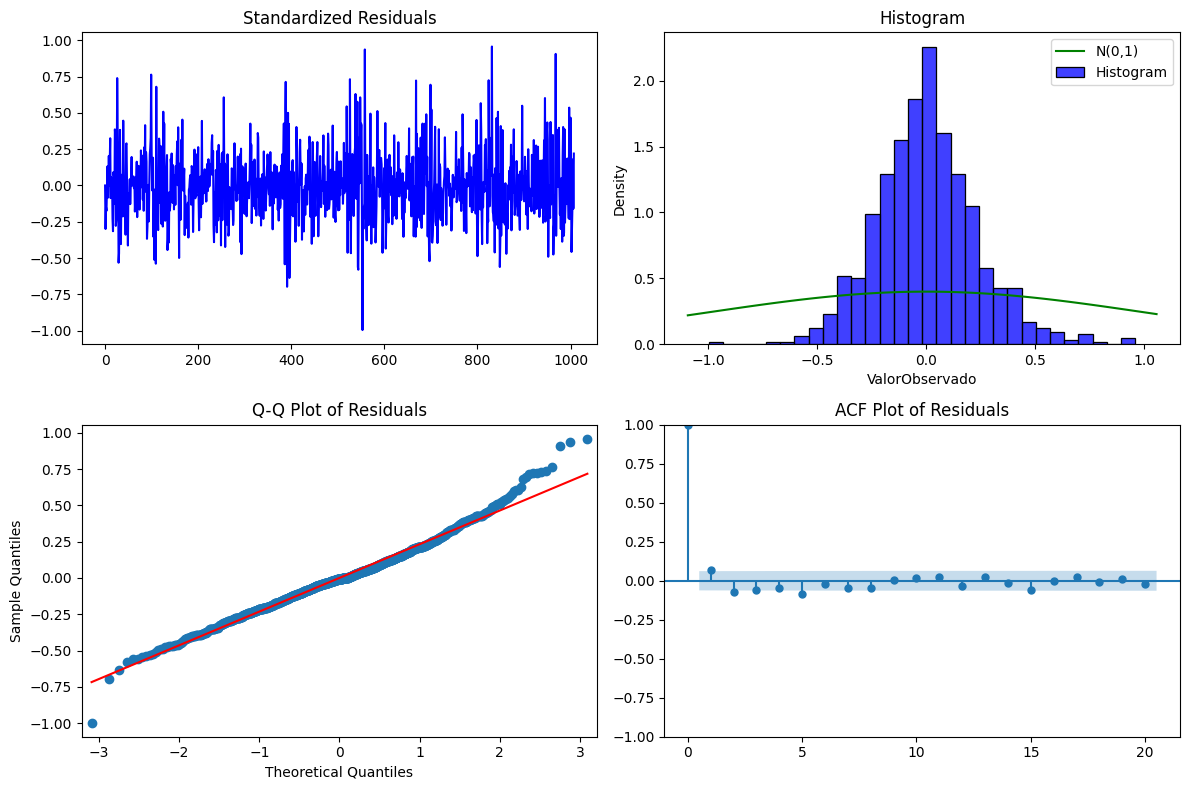

In [32]:
# Se crea gráfica de diagnóstico
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Plot 1: Standardized Residuals
axes[0, 0].plot(range(len(residuals_secondsmooth)),residuals_secondsmooth, color="blue")
axes[0, 0].set_title("Standardized Residuals")

# Plot 2: Histogram & KDE
sns.histplot(residuals_secondsmooth, stat="density", bins=30, kde=False, ax=axes[0, 1], color="blue", label = "Histogram")
xmin, xmax = axes[0, 1].get_xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, 0, 1)  # Normal distribution N(0,1)
axes[0, 1].plot(x, p, 'g-', label = "N(0,1)")
axes[0, 1].set_title("Histogram")
axes[0, 1].legend()

# Plot 3: Q-Q Plot
sm.qqplot(residuals_secondsmooth, line="s", ax=axes[1, 0])
axes[1, 0].set_title("Q-Q Plot of Residuals")

# Plot 4: ACF
sm.graphics.tsa.plot_acf(residuals_secondsmooth, lags=20, ax=axes[1, 1])
axes[1, 1].set_title("ACF Plot of Residuals")

plt.tight_layout()
plt.show()

### Forecast

In [33]:
# Se calculan los valores predichos del conjunto de validación
yhat_expsmoth2 = secondsmooth_rolling(train_data['ValorObservado'][-1008:].tolist(), validation_data['ValorObservado'].tolist(), 0.5)

In [34]:
# Se calcula el error de predicción del conjunto de validación
forecast_accuracy( np.array(yhat_expsmoth2),np.array(validation_data['ValorObservado']), "Value")

,MAE,MAPE,MSE,RMSE
Value,0.49118,0.35777,0.470293,0.685779


In [35]:
# Se calculan los valores predichos del conjunto de test
yhat_expsmoth2_test = secondsmooth_rolling(train_data['ValorObservado'][-1008:].tolist(), test_data['ValorObservado'].tolist(), 0.5)

In [36]:
# Se calcula el error de predicción del conjunto de test
forecast_accuracy( np.array(yhat_expsmoth2_test), np.array(test_data['ValorObservado']), "Value")

,MAE,MAPE,MSE,RMSE
Value,0.44284,0.325713,0.382873,0.618767


### Forecast Plot

In [37]:
# Se calculan los residuales del conjunto de test
residuals_secondsmooth_test = test_data['ValorObservado'] - yhat_expsmoth2_test

In [38]:
# Se hace la prueba de Ljung-Box
lb_test = acorr_ljungbox(residuals_secondsmooth_test, lags=[144], return_df=True)
print(lb_test)

        lb_stat  lb_pvalue
144  165.010041   0.110984


In [39]:
# Prueba de BDS (Brock-Dechert-Scheinkman)
bds_stat, bds_p_value = bds(residuals_secondsmooth_test, max_dim=2, epsilon=None, distance=1.5)
print(f"BDS Statistic: {bds_stat}")
print(f"BDS p-value: {bds_p_value}")

BDS Statistic: 3.8632215202432825
BDS p-value: 0.00011190144623338053


c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a fu

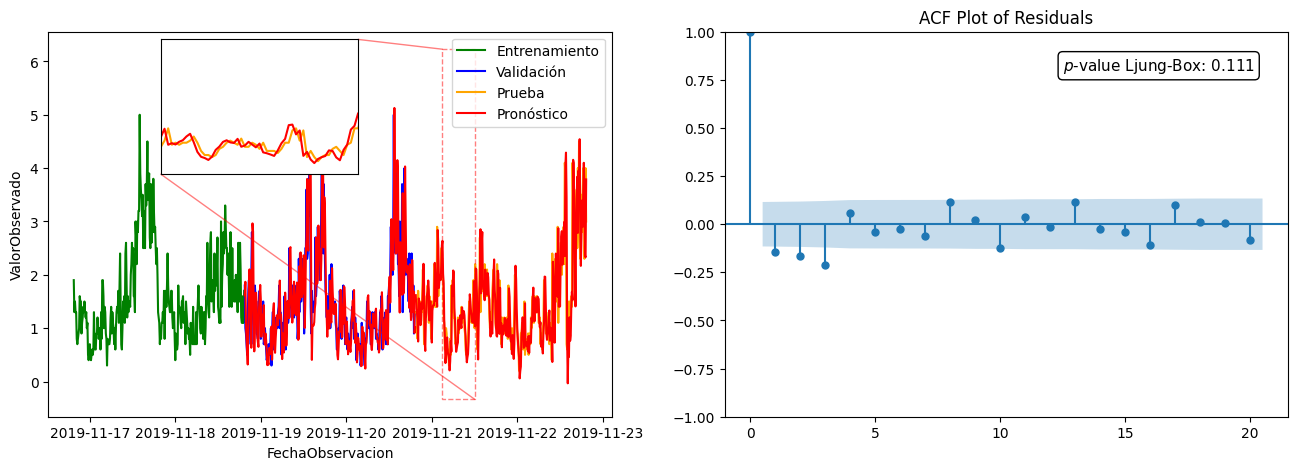

In [40]:
# Gráfica de valores observados vs predicciones
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = sns.lineplot(x=train_data['FechaObservacion'][-288:], y=train_data['ValorObservado'][-288:], label="Entrenamiento", color='g', ax=axes[0])
sns.lineplot(x=validation_data['FechaObservacion'], y=validation_data['ValorObservado'], label="Validación", color='b', ax=axes[0])
sns.lineplot(x=test_data['FechaObservacion'], y=test_data['ValorObservado'], label="Prueba", color='orange', ax=axes[0])
sns.lineplot(x=validation_data['FechaObservacion'], y=yhat_expsmoth2, label="Pronóstico", color='r', ax=axes[0])
sns.lineplot(x=test_data['FechaObservacion'], y=yhat_expsmoth2_test, color='r', ax=axes[0])

# Se añade gráfica ampliada
#  Se define la posición y tamaño ( [x, y, width, height] cada valor esta entre 0 y 1)
axins = ax.inset_axes([0.2, 0.63, 0.35, 0.35])

# Gráfiga de zona ampliada
sns.lineplot(x=train_data['FechaObservacion'][-288:], y=train_data['ValorObservado'][-288:], color='g', ax=axins)
sns.lineplot(x=validation_data['FechaObservacion'], y=validation_data['ValorObservado'], color='b', ax=axins)
sns.lineplot(x=test_data['FechaObservacion'], y=test_data['ValorObservado'], color='orange', ax=axins)
sns.lineplot(x=validation_data['FechaObservacion'], y=yhat_expsmoth2, color='r', ax=axins)
sns.lineplot(x=test_data['FechaObservacion'], y=yhat_expsmoth2_test, color='r', ax=axins)

# Se ponen los limites para la zona ampliada
axins.set_xlim(pd.Timestamp('2019-11-21 12:00:00'), pd.Timestamp('2019-11-21 3:00:00'))
ax.indicate_inset_zoom(axins, edgecolor = 'red', lw=1, ls = 'dashed')
axins.set_xticks([])
axins.set_yticks([])
axins.set_xlabel('')
axins.set_ylabel('') 

# ACF Plot
sm.graphics.tsa.plot_acf(residuals_secondsmooth_test, lags=20, ax=axes[1] )
p_value = lb_test['lb_pvalue'].values.item()
axes[1].text(0.6, 0.9, f'$p$-value Ljung-Box: {p_value:.3f}', transform=axes[1].transAxes, fontsize=11,
             bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))
axes[1].set_title("ACF Plot of Residuals")

plt.show()

## 3. Suavización exponencial de Holt-Winters de primer orden

### Selección de Modelo

In [41]:
# Función para realizar el forecast rolling
def hw1_rolling(history, test, alpha):
    
    predictions = list()
    for t in range(len(test)):
        model = SimpleExpSmoothing(history)
        model_fit = model.fit(smoothing_level=alpha, optimized=False)
        output = model_fit.forecast()
        yhat = output[0]
        predictions.append(yhat)
        obs = test[t]
        history.append(obs)
        
    return predictions

In [42]:
# Se crea array de valores de alpha
alpha_values = np.arange(0.1, 1.0, 0.1)
mse_values = {}

In [ ]:
# Bucle para evaluar cada alpha, calculando el MSE
for alpha in alpha_values:
    
    forecast = hw1_rolling(train_data['ValorObservado'][-1008:].tolist(), validation_data['ValorObservado'].tolist(), alpha)

    mse = forecast_accuracy(np.array(validation_data['ValorObservado']), np.array(forecast), "Value")['MSE'][0]
    mse_values[alpha] = mse

C:\Users\luis_\AppData\Local\Temp\ipykernel_15092\3781111563.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  mse = forecast_accuracy(np.array(validation_data['ValorObservado']), np.array(forecast), "Value")['MSE'][0]
C:\Users\luis_\AppData\Local\Temp\ipykernel_15092\3781111563.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  mse = forecast_accuracy(np.array(validation_data['ValorObservado']), np.array(forecast), "Value")['MSE'][0]
C:\Users\luis_\AppData\Local\Temp\ipykernel_15092\3781111563.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will 

In [43]:
# Modelo seleccionado, alpha = 0.4
model_expsmoth = SimpleExpSmoothing(train_data['ValorObservado'][-1008:])
model_expsmoth1 = model_expsmoth.fit(smoothing_level=0.4, optimized=False)
model_expsmoth1.summary()

c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)


Dep. Variable:,ValorObservado,No. Observations:,1008
Model:,SimpleExpSmoothing,SSE,219.973
Optimized:,False,AIC,-1530.398
Trend:,None,BIC,-1520.567
Seasonal:,None,AICC,-1530.359
Seasonal Periods:,None,Date:,"Wed, 12 Mar 2025"
Box-Cox:,False,Time:,18:27:44
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,0.4000000,alpha,False
initial_level,1.1000000,l.0,False


### Gráfica de diagnóstico

In [44]:
# Residuales de modelo seleccionado
residuals_hw1 = train_data['ValorObservado'][-1008:] - model_expsmoth1.fittedvalues

c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


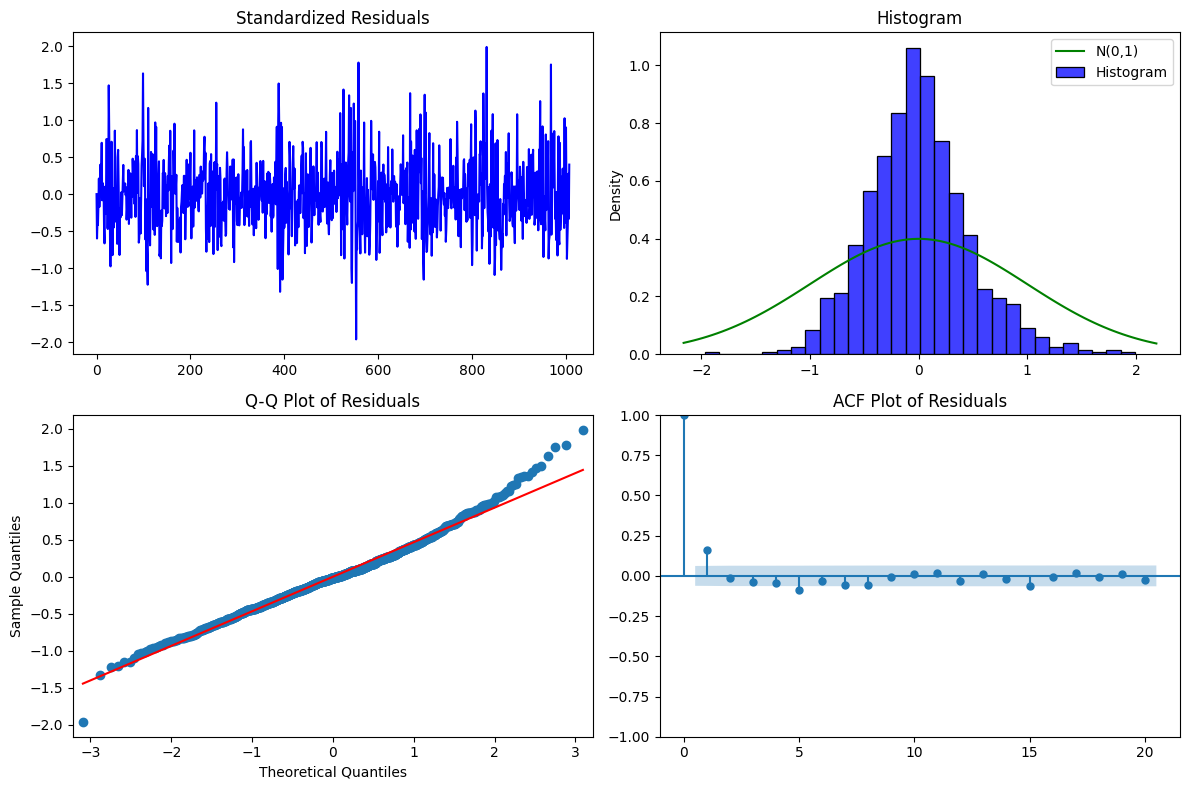

In [45]:
# Se crea gráfica de diagnóstico
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Plot 1: Standardized Residuals
axes[0, 0].plot(range(len(residuals_hw1)),residuals_hw1, color="blue")
axes[0, 0].set_title("Standardized Residuals")

# Plot 2: Histogram & KDE
sns.histplot(residuals_hw1, stat="density", bins=30, kde=False, ax=axes[0, 1], color="blue", label = "Histogram")
xmin, xmax = axes[0, 1].get_xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, 0, 1)  # Normal distribution N(0,1)
axes[0, 1].plot(x, p, 'g-', label = "N(0,1)")
axes[0, 1].set_title("Histogram")
axes[0, 1].legend()

# Plot 3: Q-Q Plot
sm.qqplot(residuals_hw1, line="s", ax=axes[1, 0])
axes[1, 0].set_title("Q-Q Plot of Residuals")

# Plot 4: ACF
sm.graphics.tsa.plot_acf(residuals_hw1, lags=20, ax=axes[1, 1])
axes[1, 1].set_title("ACF Plot of Residuals")

plt.tight_layout()
plt.show()

### Forecast

In [46]:
# Se calculan los valores predichos del conjunto de validación
yhat_hw1 = hw1_rolling(train_data['ValorObservado'][-1008:].tolist(), validation_data['ValorObservado'].tolist(), 0.4)

In [47]:
# Se calcula el error de predicción del conjunto de validación
forecast_accuracy( np.array(yhat_hw1),np.array(validation_data['ValorObservado']), "Value")

,MAE,MAPE,MSE,RMSE
Value,0.413684,0.316301,0.338862,0.582119


In [48]:
# Se calculan los valores predichos del conjunto de test
yhat_hw1_test = hw1_rolling(train_data['ValorObservado'][-1008:].tolist(), test_data['ValorObservado'].tolist(), 0.4)

In [49]:
# Se calcula el error de predicción del conjunto de test
forecast_accuracy( np.array(yhat_hw1_test), np.array(test_data['ValorObservado']), "Value")

,MAE,MAPE,MSE,RMSE
Value,0.383676,0.307116,0.28267,0.531667


### Forecast Plot

In [50]:
# Se calculan los residuales del conjunto de test
residuals_hw1_test = test_data['ValorObservado'] - yhat_hw1_test

In [51]:
# Se hace la prueba de Ljung-Box
lb_test = acorr_ljungbox(residuals_hw1_test, lags=[144], return_df=True)
print(lb_test)

        lb_stat  lb_pvalue
144  139.277187   0.595607


In [52]:
# Prueba de BDS (Brock-Dechert-Scheinkman)
bds_stat, bds_p_value = bds(residuals_hw1_test, max_dim=2, epsilon=None, distance=1.5)
print(f"BDS Statistic: {bds_stat}")
print(f"BDS p-value: {bds_p_value}")

BDS Statistic: 3.5251742424583403
BDS p-value: 0.0004232043265235631


c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a fu

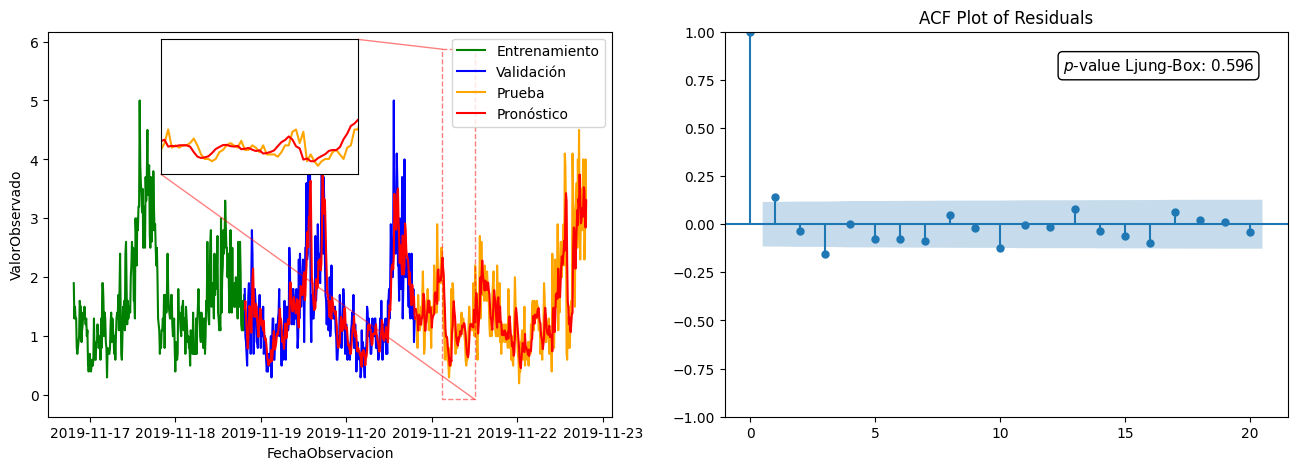

In [53]:
# Gráfica de valores observados vs predicciones
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = sns.lineplot(x=train_data['FechaObservacion'][-288:], y=train_data['ValorObservado'][-288:], label="Entrenamiento", color='g', ax=axes[0])
sns.lineplot(x=validation_data['FechaObservacion'], y=validation_data['ValorObservado'], label="Validación", color='b', ax=axes[0])
sns.lineplot(x=test_data['FechaObservacion'], y=test_data['ValorObservado'], label="Prueba", color='orange', ax=axes[0])
sns.lineplot(x=validation_data['FechaObservacion'], y=yhat_hw1, label="Pronóstico", color='r', ax=axes[0])
sns.lineplot(x=test_data['FechaObservacion'], y=yhat_hw1_test, color='r', ax=axes[0])

# Se añade gráfica ampliada
#  Se define la posición y tamaño ( [x, y, width, height] cada valor esta entre 0 y 1)
axins = ax.inset_axes([0.2, 0.63, 0.35, 0.35])

# Gráfiga de zona ampliada
sns.lineplot(x=train_data['FechaObservacion'][-288:], y=train_data['ValorObservado'][-288:], color='g', ax=axins)
sns.lineplot(x=validation_data['FechaObservacion'], y=validation_data['ValorObservado'], color='b', ax=axins)
sns.lineplot(x=test_data['FechaObservacion'], y=test_data['ValorObservado'], color='orange', ax=axins)
sns.lineplot(x=validation_data['FechaObservacion'], y=yhat_hw1, color='r', ax=axins)
sns.lineplot(x=test_data['FechaObservacion'], y=yhat_hw1_test, color='r', ax=axins)

# Se ponen los limites para la zona ampliada
axins.set_xlim(pd.Timestamp('2019-11-21 12:00:00'), pd.Timestamp('2019-11-21 3:00:00'))
ax.indicate_inset_zoom(axins, edgecolor = 'red', lw=1, ls = 'dashed')
axins.set_xticks([])
axins.set_yticks([])
axins.set_xlabel('')
axins.set_ylabel('') 

# ACF Plot
sm.graphics.tsa.plot_acf(residuals_hw1_test, lags=20, ax=axes[1] )
p_value = lb_test['lb_pvalue'].values.item()
axes[1].text(0.6, 0.9, f'$p$-value Ljung-Box: {p_value:.3f}', transform=axes[1].transAxes, fontsize=11,
             bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))
axes[1].set_title("ACF Plot of Residuals")

plt.show()

## 4. Suavización exponencial de Holt-Winters de segundo orden

### Selección de Modelo

In [54]:
# Función para realizar el forecast rolling
def hw2_rolling(history, test, alpha, beta):
    
    predictions = list()
    for t in range(len(test)):
        model = ExponentialSmoothing(history, trend='add', seasonal=None)
        model_fit = model.fit(smoothing_level=alpha, smoothing_trend=beta)
        output = model_fit.forecast()
        yhat = output[0]
        predictions.append(yhat)
        obs = test[t]
        history.append(obs)
        
    return predictions

In [55]:
# Se crea array de valores de alphas y betas
alphas = np.arange(0.01, 1, 1)
betas = np.arange(0.01, 1, 1)
mse_values = {}

In [56]:
# Función para evaluar cada parámetro, calculando el MSE
def des_optimizer(train_data, validation_data, alpha_range, beta_range):
    best_alpha, best_beta, best_mse = None, None, float("inf")
    for alpha in alpha_range:
            for beta in beta_range:
                # Predicción del conjunto de validación
                forecast = hw2_rolling(train_data, validation_data, alpha, beta)
                
                # Se calcula el MSE en el conjunto de validación
                mse = forecast_accuracy(np.array(validation_data), np.array(forecast), "Value")['MSE'][0]
                
                # Si esta combinación de parámetros da el mejor MSE, actualiza los mejores parámetros
                if mse < best_mse:
                    best_mse = mse
                    best_alpha = alpha
                    best_beta = beta
    return best_alpha, best_beta, best_mse

In [ ]:
# Evaluando la función para determinar los parámetros
des_optimizer(train_data['ValorObservado'][-1008:].tolist(), validation_data['ValorObservado'].tolist(), alphas, betas)

In [57]:
# Modelo seleccionado, alpha = 0.4, beta = 0.1
model_hw2 = ExponentialSmoothing(train_data['ValorObservado'][-1008:], trend='add', seasonal=None)
model_hw2 = model_hw2.fit(smoothing_level=0.4, smoothing_trend = 0.1, optimized=False)
model_hw2.summary()

c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)


Dep. Variable:,ValorObservado,No. Observations:,1008
Model:,ExponentialSmoothing,SSE,237.278
Optimized:,False,AIC,-1450.064
Trend:,Additive,BIC,-1430.401
Seasonal:,None,AICC,-1449.980
Seasonal Periods:,None,Date:,"Wed, 12 Mar 2025"
Box-Cox:,False,Time:,18:28:05
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,0.4000000,alpha,False
smoothing_trend,0.1000000,beta,False


### Gráfica de diagnóstico

In [58]:
# Residuales de modelo seleccionado
residuals_hw2 = train_data['ValorObservado'][-1008:] - model_hw2.fittedvalues

c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


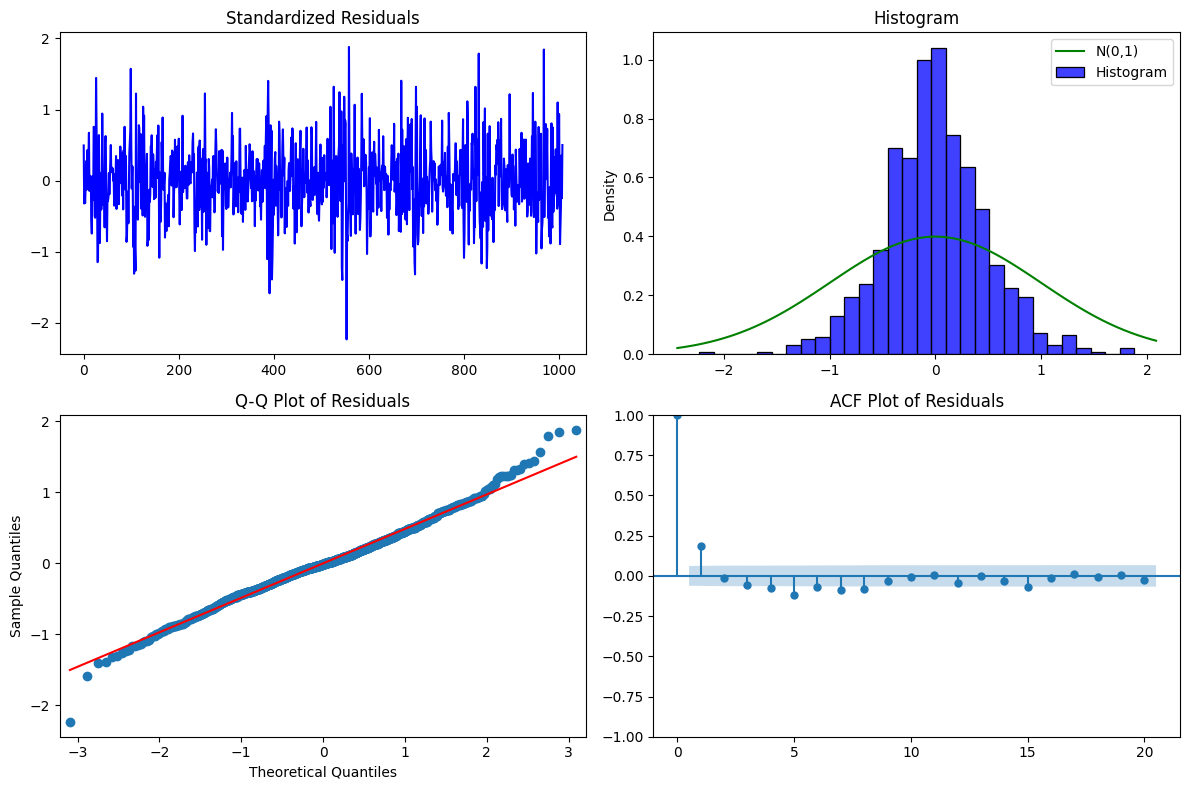

In [59]:
# Se crea gráfica de diagnóstico
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Plot 1: Standardized Residuals
axes[0, 0].plot(range(len(residuals_hw2)),residuals_hw2, color="blue")
axes[0, 0].set_title("Standardized Residuals")

# Plot 2: Histogram & KDE
sns.histplot(residuals_hw2, stat="density", bins=30, kde=False, ax=axes[0, 1], color="blue", label = "Histogram")
xmin, xmax = axes[0, 1].get_xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, 0, 1)  # Normal distribution N(0,1)
axes[0, 1].plot(x, p, 'g-', label = "N(0,1)")
axes[0, 1].set_title("Histogram")
axes[0, 1].legend()

# Plot 3: Q-Q Plot
sm.qqplot(residuals_hw2, line="s", ax=axes[1, 0])
axes[1, 0].set_title("Q-Q Plot of Residuals")

# Plot 4: ACF
sm.graphics.tsa.plot_acf(residuals_hw2, lags=20, ax=axes[1, 1])
axes[1, 1].set_title("ACF Plot of Residuals")

plt.tight_layout()
plt.show()

### Forecast

In [60]:
# Se calculan los valores predichos del conjunto de validación
yhat_hw2 = hw2_rolling(train_data['ValorObservado'][-1008:].tolist(), validation_data['ValorObservado'].tolist(), 0.4, 0.1)

In [61]:
# Se calcula el error de predicción del conjunto de validación
forecast_accuracy( np.array(yhat_hw2), np.array(validation_data['ValorObservado']), "Value")

,MAE,MAPE,MSE,RMSE
Value,0.42518,0.319342,0.364492,0.603732


In [62]:
# Se calculan los valores predichos del conjunto de test
yhat_hw2_test = hw2_rolling(train_data['ValorObservado'][-1008:].tolist(), test_data['ValorObservado'].tolist(), 0.4, 0.1)

In [63]:
# Se calcula el error de predicción del conjunto de test
forecast_accuracy(np.array(yhat_hw2_test), np.array( test_data['ValorObservado']), "Value")

,MAE,MAPE,MSE,RMSE
Value,0.398003,0.314298,0.307679,0.554689


### Forecast Plot

In [64]:
# Se calculan los residuales del conjunto de test
residuals_hw2_test = test_data['ValorObservado'] - yhat_hw2_test

In [65]:
# Se hace la prueba de Ljung-Box
lb_test = acorr_ljungbox(residuals_hw2_test, lags=[144], return_df=True)
print(lb_test)

       lb_stat  lb_pvalue
144  150.53803   0.337708


In [66]:
# Prueba de BDS (Brock-Dechert-Scheinkman)
bds_stat, bds_p_value = bds(residuals_hw2_test, max_dim=2, epsilon=None, distance=1.5)
print(f"BDS Statistic: {bds_stat}")
print(f"BDS p-value: {bds_p_value}")

BDS Statistic: 4.095006040277596
BDS p-value: 4.2215738145017516e-05


c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a fu

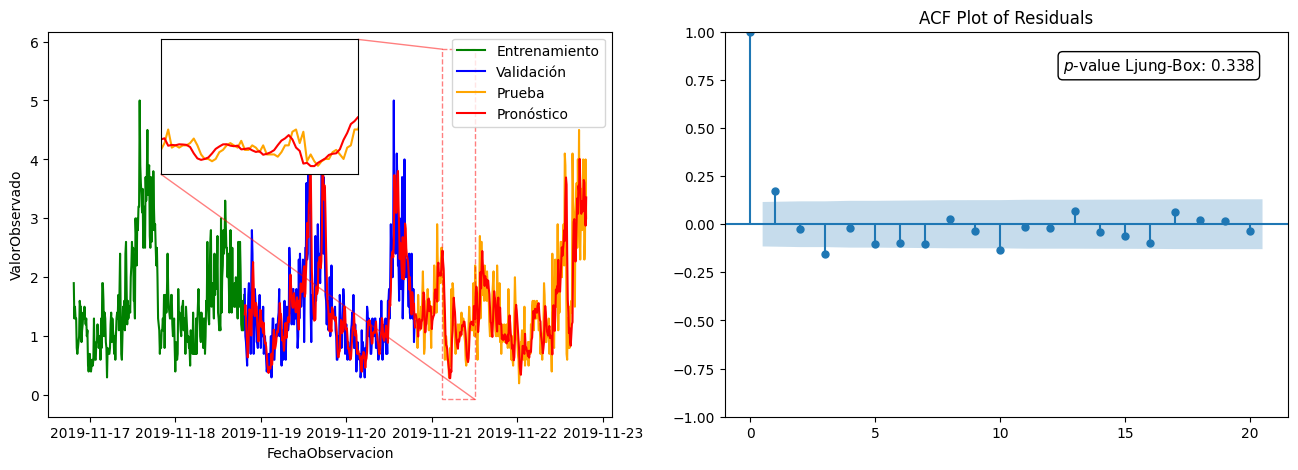

In [67]:
# Gráfica de valores observados vs predicciones
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = sns.lineplot(x=train_data['FechaObservacion'][-288:], y=train_data['ValorObservado'][-288:], label="Entrenamiento", color='g', ax=axes[0])
sns.lineplot(x=validation_data['FechaObservacion'], y=validation_data['ValorObservado'], label="Validación", color='b', ax=axes[0])
sns.lineplot(x=test_data['FechaObservacion'], y=test_data['ValorObservado'], label="Prueba", color='orange', ax=axes[0])
sns.lineplot(x=validation_data['FechaObservacion'], y=yhat_hw2, label="Pronóstico", color='r', ax=axes[0])
sns.lineplot(x=test_data['FechaObservacion'], y=yhat_hw2_test, color='r', ax=axes[0])

# Se añade gráfica ampliada
#  Se define la posición y tamaño ( [x, y, width, height] cada valor esta entre 0 y 1)
axins = ax.inset_axes([0.2, 0.63, 0.35, 0.35])

# Gráfiga de zona ampliada
sns.lineplot(x=train_data['FechaObservacion'][-288:], y=train_data['ValorObservado'][-288:], color='g', ax=axins)
sns.lineplot(x=validation_data['FechaObservacion'], y=validation_data['ValorObservado'], color='b', ax=axins)
sns.lineplot(x=test_data['FechaObservacion'], y=test_data['ValorObservado'], color='orange', ax=axins)
sns.lineplot(x=validation_data['FechaObservacion'], y=yhat_hw2, color='r', ax=axins)
sns.lineplot(x=test_data['FechaObservacion'], y=yhat_hw2_test, color='r', ax=axins)

# Se ponen los limites para la zona ampliada
axins.set_xlim(pd.Timestamp('2019-11-21 12:00:00'), pd.Timestamp('2019-11-21 3:00:00'))
ax.indicate_inset_zoom(axins, edgecolor = 'red', lw=1, ls = 'dashed')
axins.set_xticks([])
axins.set_yticks([])
axins.set_xlabel('')
axins.set_ylabel('') 

# ACF Plot
sm.graphics.tsa.plot_acf(residuals_hw2_test, lags=20, ax=axes[1] )
p_value = lb_test['lb_pvalue'].values.item()
axes[1].text(0.6, 0.9, f'$p$-value Ljung-Box: {p_value:.3f}', transform=axes[1].transAxes, fontsize=11,
             bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))
axes[1].set_title("ACF Plot of Residuals")

plt.show()

## 5. Suavización exponencial de Holt-Winters de tercer orden

### Selección de Modelo

In [68]:
# Función para realizar el forecast rolling
def hw3_rolling(history, test, alpha, beta, gamma):
    
    predictions = list()
    for t in range(len(test)):
        model = ExponentialSmoothing(history, trend='add', seasonal='add', seasonal_periods=6)
        model_fit = model.fit(smoothing_level=alpha, smoothing_trend=beta, smoothing_seasonal=gamma)
        output = model_fit.forecast()
        yhat = output[0]
        predictions.append(yhat)
        obs = test[t]
        history.append(obs)
        
    return predictions

In [69]:
# Se crea array de valores de alphas, betas y gammas
alphas = np.arange(0.3, 0.32, 0.1)
betas = np.arange(0.01, 0.5, 0.1)
gammas = np.arange(0.01, 0.5, 0.1)
mse_values = {}

In [70]:
# Función para evaluar cada parámetro, calculando el MSE
def tes_optimizer(train_data, validation_data, alpha_range, beta_range, gamma_range):
    best_alpha, best_beta, best_gamma, best_mse = None, None, None, float("inf")
    for alpha in alpha_range:
            for beta in beta_range:
                for gamma in gamma_range:
                    # Predicción del conjunto de validación
                    forecast = hw3_rolling(train_data, validation_data, alpha, beta, gamma)
                    
                    # # Se calcula el MSE en el conjunto de validación
                    mse = forecast_accuracy(np.array(validation_data), np.array(forecast), "Value")['MSE'][0]
                    
                    # Si esta combinación de parámetros da el mejor MSE, actualiza los mejores parámetros
                    if mse < best_mse:
                        best_mse = mse
                        best_alpha = alpha
                        best_beta = beta
                        best_gamma = gamma
    return best_alpha, best_beta, best_gamma, best_mse

In [ ]:
# Evaluando la función para determinar los parámetros
tes_optimizer(train_data['ValorObservado'][-1008:].tolist(), validation_data['ValorObservado'].tolist(), alphas, betas, gammas)

In [71]:
# Modelo seleccionado, alpha = 0.4, beta = 0.1 y gamma = 0.1
model_hw3 = ExponentialSmoothing(train_data['ValorObservado'][-1008:], trend='add', seasonal='add', seasonal_periods=6)
model_hw3 = model_hw3.fit(smoothing_level=0.4, smoothing_trend = 0.1, smoothing_seasonal = 0.1, optimized=False)
model_hw2.summary()

c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)


Dep. Variable:,ValorObservado,No. Observations:,1008
Model:,ExponentialSmoothing,SSE,237.278
Optimized:,False,AIC,-1450.064
Trend:,Additive,BIC,-1430.401
Seasonal:,None,AICC,-1449.980
Seasonal Periods:,None,Date:,"Wed, 12 Mar 2025"
Box-Cox:,False,Time:,18:28:27
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,0.4000000,alpha,False
smoothing_trend,0.1000000,beta,False


### Gráfica de diagnóstico

In [72]:
# Residuales de modelo seleccionado
residuals_hw3 = train_data['ValorObservado'][-1008:] - model_hw3.fittedvalues

c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


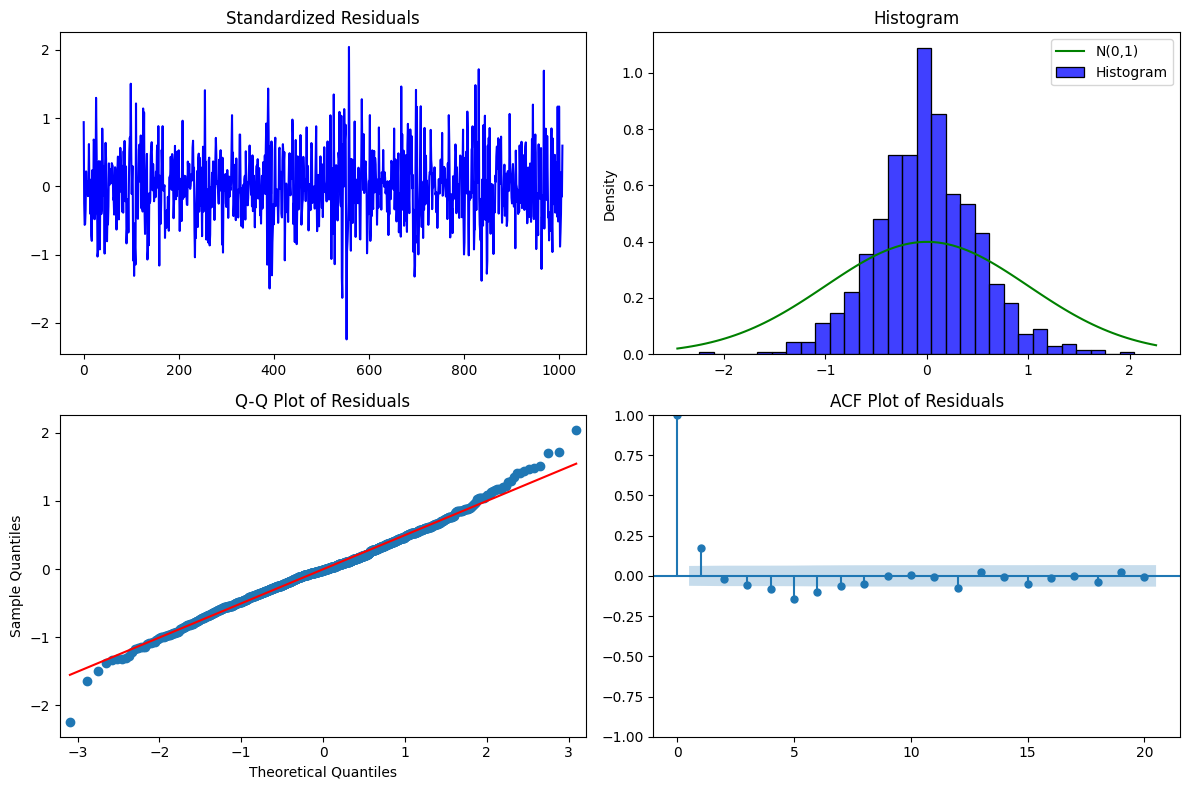

In [73]:
# Se crea gráfica de diagnóstico
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Plot 1: Standardized Residuals
axes[0, 0].plot(range(len(residuals_hw3)),residuals_hw3, color="blue")
axes[0, 0].set_title("Standardized Residuals")

# Plot 2: Histogram & KDE
sns.histplot(residuals_hw3, stat="density", bins=30, kde=False, ax=axes[0, 1], color="blue", label = "Histogram")
xmin, xmax = axes[0, 1].get_xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, 0, 1)  # Normal distribution N(0,1)
axes[0, 1].plot(x, p, 'g-', label = "N(0,1)")
axes[0, 1].set_title("Histogram")
axes[0, 1].legend()

# Plot 3: Q-Q Plot
sm.qqplot(residuals_hw3, line="s", ax=axes[1, 0])
axes[1, 0].set_title("Q-Q Plot of Residuals")

# Plot 4: ACF
sm.graphics.tsa.plot_acf(residuals_hw3, lags=20, ax=axes[1, 1])
axes[1, 1].set_title("ACF Plot of Residuals")

plt.tight_layout()
plt.show()

### Forecast

In [74]:
# Se calculan los valores predichos del conjunto de validación
yhat_hw3 = hw3_rolling(train_data['ValorObservado'][-1008:].tolist(), validation_data['ValorObservado'].tolist(), 0.4 , 0.1 , 0.1)

In [75]:
# Se calcula el error de predicción del conjunto de validación
forecast_accuracy( np.array(yhat_hw3), np.array(validation_data['ValorObservado']), "Value")

,MAE,MAPE,MSE,RMSE
Value,0.441337,0.332445,0.377783,0.614641


In [76]:
# Se calculan los valores predichos del conjunto de test
yhat_hw3_test = hw3_rolling(train_data['ValorObservado'][-1008:].tolist(), test_data['ValorObservado'].tolist(), 0.4, 0.1, 0.1)

In [77]:
# Se calcula el error de predicción del conjunto de test
forecast_accuracy(np.array(yhat_hw3_test), np.array( test_data['ValorObservado']), "Value")

,MAE,MAPE,MSE,RMSE
Value,0.408343,0.324873,0.321345,0.566873


### Forecast Plot

In [78]:
# Se calculan los residuales del conjunto de test
residuals_hw3_test =  test_data['ValorObservado'] - yhat_hw3_test

In [79]:
# Se hace la prueba de Ljung-Box
lb_test = acorr_ljungbox(residuals_hw3_test, lags=[144], return_df=True)
print(lb_test)

        lb_stat  lb_pvalue
144  169.242083   0.073924


In [80]:
# Prueba de BDS (Brock-Dechert-Scheinkman)
bds_stat, bds_p_value = bds(residuals_hw3_test, max_dim=2, epsilon=None, distance=1.5)
print(f"BDS Statistic: {bds_stat}")
print(f"BDS p-value: {bds_p_value}")

BDS Statistic: 4.012010436323269
BDS p-value: 6.020383787232898e-05


c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a fu

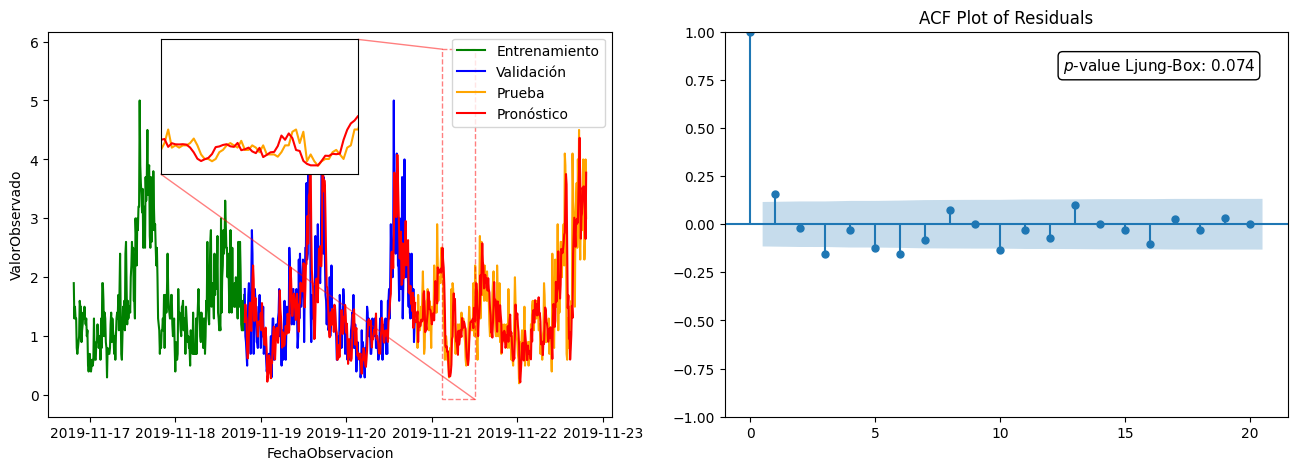

In [81]:
# Gráfica de valores observados vs predicciones
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = sns.lineplot(x=train_data['FechaObservacion'][-288:], y=train_data['ValorObservado'][-288:], label="Entrenamiento", color='g', ax=axes[0])
sns.lineplot(x=validation_data['FechaObservacion'], y=validation_data['ValorObservado'], label="Validación", color='b', ax=axes[0])
sns.lineplot(x=test_data['FechaObservacion'], y=test_data['ValorObservado'], label="Prueba", color='orange', ax=axes[0])
sns.lineplot(x=validation_data['FechaObservacion'], y=yhat_hw3, label="Pronóstico", color='r', ax=axes[0])
sns.lineplot(x=test_data['FechaObservacion'], y=yhat_hw3_test, color='r', ax=axes[0])

# Se añade gráfica ampliada
#  Se define la posición y tamaño ( [x, y, width, height] cada valor esta entre 0 y 1)
axins = ax.inset_axes([0.2, 0.63, 0.35, 0.35])

# Gráfiga de zona ampliada
sns.lineplot(x=train_data['FechaObservacion'][-288:], y=train_data['ValorObservado'][-288:], color='g', ax=axins)
sns.lineplot(x=validation_data['FechaObservacion'], y=validation_data['ValorObservado'], color='b', ax=axins)
sns.lineplot(x=test_data['FechaObservacion'], y=test_data['ValorObservado'], color='orange', ax=axins)
sns.lineplot(x=validation_data['FechaObservacion'], y=yhat_hw3, color='r', ax=axins)
sns.lineplot(x=test_data['FechaObservacion'], y=yhat_hw3_test, color='r', ax=axins)

# Se ponen los limites para la zona ampliada
axins.set_xlim(pd.Timestamp('2019-11-21 12:00:00'), pd.Timestamp('2019-11-21 3:00:00'))
ax.indicate_inset_zoom(axins, edgecolor = 'red', lw=1, ls = 'dashed')
axins.set_xticks([])
axins.set_yticks([])
axins.set_xlabel('')
axins.set_ylabel('') 

# ACF Plot
sm.graphics.tsa.plot_acf(residuals_hw3_test, lags=20, ax=axes[1] )
p_value = lb_test['lb_pvalue'].values.item()
axes[1].text(0.6, 0.9, f'$p$-value Ljung-Box: {p_value:.3f}', transform=axes[1].transAxes, fontsize=11,
             bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))
axes[1].set_title("ACF Plot of Residuals")

plt.show()

## 6. ARIMA

### Selección de Modelo

In [82]:
# Función para realizar el forecast rolling
def arima_rolling(history, test):
    
    predictions = list()
    for t in range(len(test)):
        model = ARIMA(history, order=(2, 0, 2))
        model_fit = model.fit()
        output = model_fit.forecast()
        yhat = output[0]
        predictions.append(yhat)
        obs = test[t]
        history.append(obs)
        print('predicted=%f, expected=%f' % (yhat, obs))
        
    return predictions

In [ ]:
## Bucle para determinar el mejor modelo ARIMA, minimizando el AIC
aicVal=[]
for d in range(0,3):
    for ari in range(0, 3):
        for maj in range(0,3):
            try:
                arima_obj = smtsa.ARIMA(train_data['ValorObservado'].tolist(), order=(ari, d, maj))
                arima_obj_fit=arima_obj.fit()
                aicVal.append([ari, d, maj, arima_obj_fit.aic])
            except ValueError:
                pass

c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [ ]:
# Mostrando los modelos evaluados y su AIC
dfAIC = pd.DataFrame(aicVal, columns=['AR(p)', 'd', 'MA(q)', 'AIC'])
dfAIC

,AR(p),d,MA(q),AIC
0,0,0,0,1.889094e+06
1,0,0,1,1.534251e+06
2,0,0,2,1.358493e+06
3,1,0,0,1.074956e+06
4,1,0,1,1.073631e+06
5,1,0,2,1.071466e+06
6,2,0,0,1.073836e+06
7,2,0,1,1.071000e+06
8,2,0,2,1.070819e+06
9,0,1,0,1.087040e+06


In [ ]:
# Mostrando el mejor modelo basado en AIC
print('Best ARIMA parameters based on AIC:\n')
dfAIC[dfAIC.AIC == dfAIC.AIC.min()]

Best ARIMA parameters based on AIC:



,AR(p),d,MA(q),AIC
8,2,0,2,1.070819e+06


In [83]:
# Resumen de modelo seleccionado p = 2, d = 0, q = 2
modelArima = ARIMA(train_data['ValorObservado'][-1008:].tolist(), order=(2, 0, 2))
modelArimafit = modelArima.fit()
modelArimafit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1008
Model:                 ARIMA(2, 0, 2)   Log Likelihood                -635.281
Date:                Wed, 12 Mar 2025   AIC                           1282.561
Time:                        18:28:52   BIC                           1312.056
Sample:                             0   HQIC                          1293.767
                               - 1008                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.4211      0.154      9.232      0.000       1.119       1.723
ar.L1          1.3675      0.219      6.246      0.000       0.938       1.797
ar.L2         -0.3945      0.206     -1.917      0.055      -0.798       0.009
ma.L1         -0.8285      0.220     -3.768      0.000      -1.259      -0.398
ma.L2          0.0800      0.108      0.740      0.459      -0.132       0.292
sigma2         0.2063      0.008     26.149      0.000       0.191       0.222
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):               139.66
Prob(Q):                              0.95   Prob(JB):                         0.00
Heteroskedasticity (H):               1.36   Skew:                             0.66
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.26
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### Gráfica de diagnóstico

In [84]:
# Residuales de modelo seleccionado
residuals_arima = train_data['ValorObservado'][-1008:] - modelArimafit.fittedvalues

c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


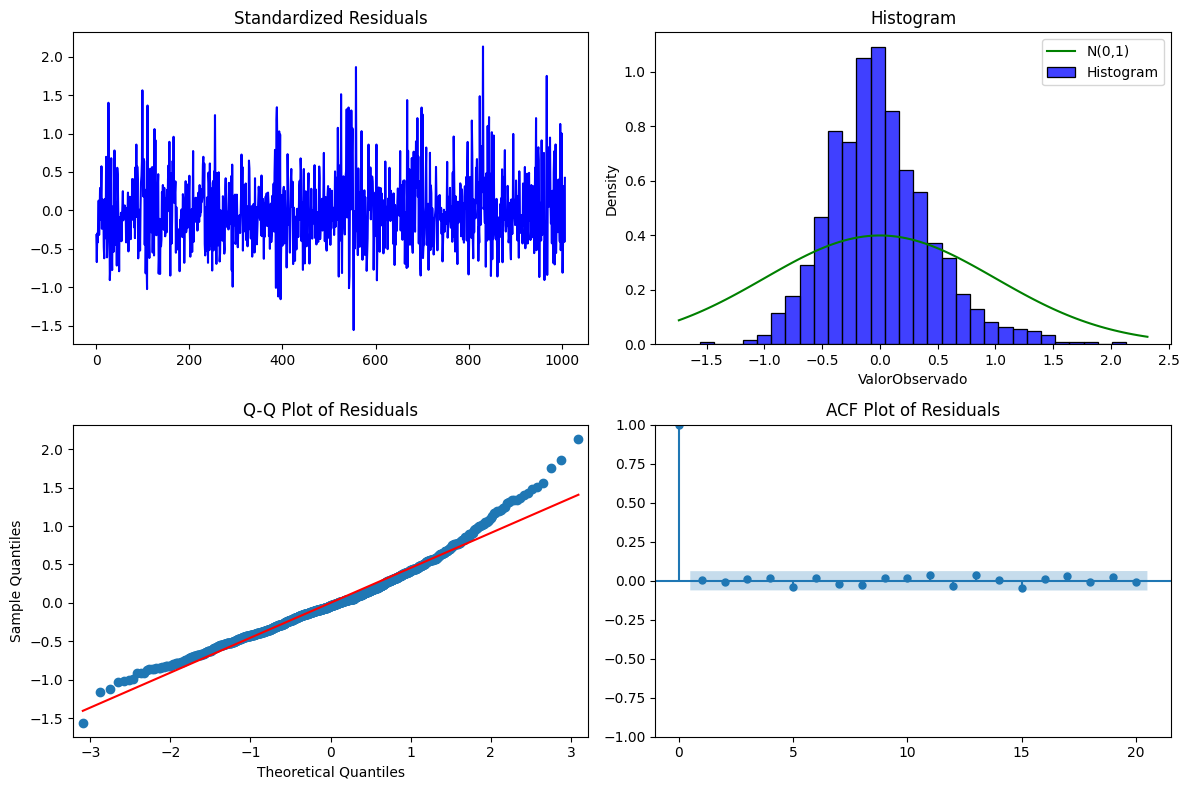

In [85]:
# Se crea gráfica de diagnóstico
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Plot 1: Standardized Residuals
axes[0, 0].plot(range(len(residuals_arima)),residuals_arima, color="blue")
axes[0, 0].set_title("Standardized Residuals")

# Plot 2: Histogram & KDE
sns.histplot(residuals_arima, stat="density", bins=30, kde=False, ax=axes[0, 1], color="blue", label = "Histogram")
xmin, xmax = axes[0, 1].get_xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, 0, 1)  # Normal distribution N(0,1)
axes[0, 1].plot(x, p, 'g-', label = "N(0,1)")
axes[0, 1].set_title("Histogram")
axes[0, 1].legend()

# Plot 3: Q-Q Plot
sm.qqplot(residuals_arima, line="s", ax=axes[1, 0])
axes[1, 0].set_title("Q-Q Plot of Residuals")

# Plot 4: ACF
sm.graphics.tsa.plot_acf(residuals_arima, lags=20, ax=axes[1, 1])
axes[1, 1].set_title("ACF Plot of Residuals")

plt.tight_layout()
plt.show()

### Forecast

In [86]:
# Se calculan los valores predichos del conjunto de validación
yhat_arima  = arima_rolling(train_data['ValorObservado'][-1008:].tolist(), validation_data['ValorObservado'].tolist())

predicted=1.545177, expected=1.800000
predicted=1.652603, expected=1.000000
predicted=1.254964, expected=0.900000
predicted=1.117859, expected=0.700000
predicted=0.956784, expected=0.500000
predicted=0.788759, expected=1.200000
predicted=1.107095, expected=1.700000
predicted=1.431894, expected=1.900000
predicted=1.626409, expected=1.300000
predicted=1.369122, expected=1.100000
predicted=1.228417, expected=0.700000
predicted=0.976426, expected=2.000000
predicted=1.615333, expected=2.800000
predicted=2.175894, expected=2.400000
predicted=2.112870, expected=1.200000
predicted=1.498326, expected=0.700000
predicted=1.125036, expected=1.300000
predicted=1.351224, expected=1.800000
predicted=1.621081, expected=1.600000
predicted=1.554144, expected=1.400000
predicted=1.450514, expected=0.900000
predicted=1.159143, expected=0.900000
predicted=1.096510, expected=0.800000
predicted=0.999061, expected=1.500000
predicted=1.346842, expected=1.500000
predicted=1.392853, expected=1.700000
predicted=1.

In [87]:
# Se calcula el error de predicción del conjunto de validación
forecast_accuracy( np.array(yhat_arima), np.array(validation_data['ValorObservado']), "Value")

,MAE,MAPE,MSE,RMSE
Value,0.401038,0.311518,0.31966,0.565385


In [88]:
# Se calculan los valores predichos del conjunto de test
yhat_arima_test  = arima_rolling(train_data['ValorObservado'][-1008:].tolist(), test_data['ValorObservado'].tolist())

predicted=1.545177, expected=1.300000
predicted=1.382212, expected=1.300000
predicted=1.351550, expected=1.200000
predicted=1.285214, expected=0.800000
predicted=1.048007, expected=1.700000
predicted=1.468186, expected=1.400000
predicted=1.391299, expected=1.100000
predicted=1.226082, expected=1.100000
predicted=1.189812, expected=1.200000
predicted=1.226421, expected=1.500000
predicted=1.389872, expected=1.300000
predicted=1.320480, expected=1.700000
predicted=1.528652, expected=2.100000
predicted=1.796907, expected=1.600000
predicted=1.606896, expected=0.700000
predicted=1.099807, expected=0.800000
predicted=1.034756, expected=1.400000
predicted=1.312016, expected=1.300000
predicted=1.298075, expected=1.600000
predicted=1.463579, expected=1.600000
predicted=1.504799, expected=1.800000
predicted=1.635732, expected=1.600000
predicted=1.568350, expected=1.100000
predicted=1.296610, expected=1.600000
predicted=1.507380, expected=1.500000
predicted=1.485722, expected=1.200000
predicted=1.

In [89]:
# Se calcula el error de predicción del conjunto de test
forecast_accuracy(np.array(yhat_arima_test), np.array(test_data['ValorObservado']), "Value")

,MAE,MAPE,MSE,RMSE
Value,0.369636,0.296831,0.270649,0.520239


### Forecast plot

In [90]:
# Se calculan los residuales del conjunto de test
residuals_arima_test =  test_data['ValorObservado'] - yhat_arima_test

In [91]:
# Se hace la prueba de Ljung-Box
lb_test = acorr_ljungbox(residuals_arima_test, lags=[144], return_df=True)
print(lb_test)

        lb_stat  lb_pvalue
144  119.374208   0.933619


In [92]:
# Prueba de BDS (Brock-Dechert-Scheinkman)
bds_stat, bds_p_value = bds(residuals_arima_test, max_dim=2, epsilon=None, distance=1.5)
print(f"BDS Statistic: {bds_stat}")
print(f"BDS p-value: {bds_p_value}")

BDS Statistic: 2.5038968579703518
BDS p-value: 0.012283383684237077


c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a fu

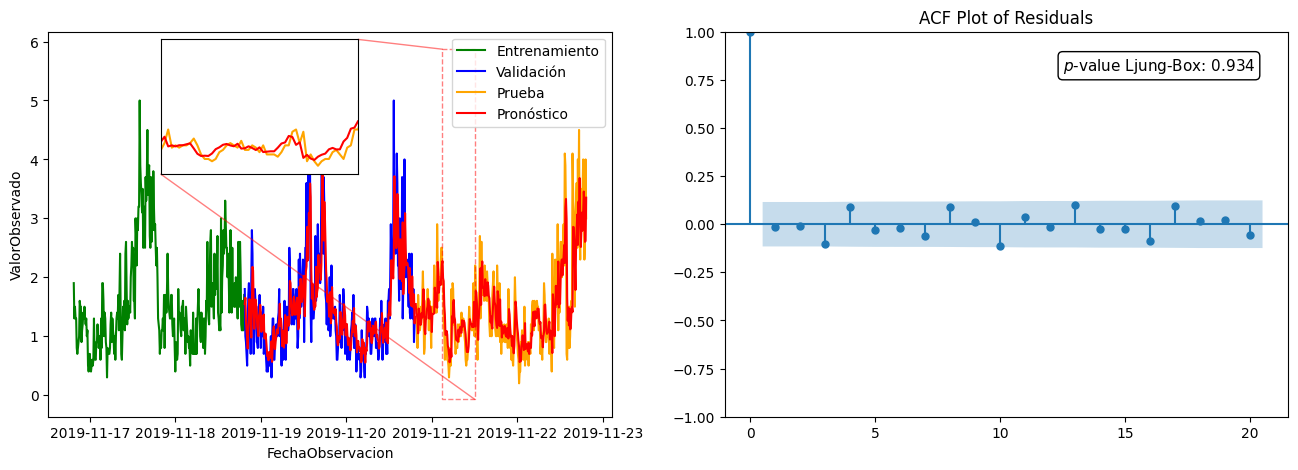

In [94]:
# Gráfica de valores observados vs predicciones
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = sns.lineplot(x=train_data['FechaObservacion'][-288:], y=train_data['ValorObservado'][-288:], label="Entrenamiento", color='g', ax=axes[0])
sns.lineplot(x=validation_data['FechaObservacion'], y=validation_data['ValorObservado'], label="Validación", color='b', ax=axes[0])
sns.lineplot(x=test_data['FechaObservacion'], y=test_data['ValorObservado'], label="Prueba", color='orange', ax=axes[0])
sns.lineplot(x=validation_data['FechaObservacion'], y=yhat_arima, label="Pronóstico", color='r', ax=axes[0])
sns.lineplot(x=test_data['FechaObservacion'], y=yhat_arima_test, color='r', ax=axes[0])

# Se añade gráfica ampliada
#  Se define la posición y tamaño ( [x, y, width, height] cada valor esta entre 0 y 1)
axins = ax.inset_axes([0.2, 0.63, 0.35, 0.35])

# Gráfiga de zona ampliada
sns.lineplot(x=train_data['FechaObservacion'][-288:], y=train_data['ValorObservado'][-288:], color='g', ax=axins)
sns.lineplot(x=validation_data['FechaObservacion'], y=validation_data['ValorObservado'], color='b', ax=axins)
sns.lineplot(x=test_data['FechaObservacion'], y=test_data['ValorObservado'], color='orange', ax=axins)
sns.lineplot(x=validation_data['FechaObservacion'], y=yhat_arima, color='r', ax=axins)
sns.lineplot(x=test_data['FechaObservacion'], y=yhat_arima_test, color='r', ax=axins)

# Se ponen los limites para la zona ampliada
axins.set_xlim(pd.Timestamp('2019-11-21 12:00:00'), pd.Timestamp('2019-11-21 3:00:00'))
ax.indicate_inset_zoom(axins, edgecolor = 'red', lw=1, ls = 'dashed')
axins.set_xticks([])
axins.set_yticks([])
axins.set_xlabel('')
axins.set_ylabel('') 

# ACF Plot
sm.graphics.tsa.plot_acf(residuals_arima_test, lags=20, ax=axes[1] )
p_value = lb_test['lb_pvalue'].values.item()
axes[1].text(0.6, 0.9, f'$p$-value Ljung-Box: {p_value:.3f}', transform=axes[1].transAxes, fontsize=11,
             bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))
axes[1].set_title("ACF Plot of Residuals")

plt.show()

## 7. GARCH

### Selección de modelo

In [95]:
# Función para realizar el forecast rolling
def garch_rolling(history, test):
    
    predictions = list()
    for t in range(len(test)):
        model = arch_model(history, p = 2, q = 1)
        model_fit = model.fit()
        output = model_fit.forecast(horizon=1)
        yhat = np.sqrt(output.variance.iloc[-1].values)[0]
        predictions.append(yhat)
        obs = test[t]
        history.append(obs)
        print('predicted=%f, expected=%f' % (yhat, obs))
        
    return predictions

In [ ]:
## Función para determinar el mejor modelo GARCH, minimizando el AIC
aicVal=[]
for pi in range(1, 5):
    for qj in range(1,5):
        try:
            garch_obj = arch_model(train_data['ValorObservado'].tolist(), p = pi, q = qj)
            garch_obj_fit = garch_obj.fit()
            aicVal.append([pi, qj, garch_obj_fit.aic])
        except ValueError:
            pass

Iteration:      1,   Func. Count:      6,   Neg. LLF: 4331530653.404744
Iteration:      2,   Func. Count:     21,   Neg. LLF: 2019253.5271167012
Iteration:      3,   Func. Count:     26,   Neg. LLF: 2239561.8328918675
Iteration:      4,   Func. Count:     32,   Neg. LLF: 272141913930.9025
Iteration:      5,   Func. Count:     47,   Neg. LLF: 2.9639037870917187e+23
Iteration:      6,   Func. Count:     62,   Neg. LLF: 1317128321.2137678
Iteration:      7,   Func. Count:     68,   Neg. LLF: 17131801062.894638
Iteration:      8,   Func. Count:     82,   Neg. LLF: 321008363376189.94
Iteration:      9,   Func. Count:     89,   Neg. LLF: 189738557093.85535
Iteration:     10,   Func. Count:     95,   Neg. LLF: 5.554185790606803e+19
Iteration:     11,   Func. Count:    107,   Neg. LLF: 5833137.141717062
Iteration:     12,   Func. Count:    116,   Neg. LLF: 757011.9568315182
Optimization terminated successfully    (Exit mode 0)
            Current function value: 757011.9542964923
            I

c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(


Iteration:      1,   Func. Count:      9,   Neg. LLF: 4158842772.892116
Iteration:      2,   Func. Count:     27,   Neg. LLF: 2010612.72468012
Iteration:      3,   Func. Count:     35,   Neg. LLF: 736093092442.657
Iteration:      4,   Func. Count:     50,   Neg. LLF: 4123687889.07527
Iteration:      5,   Func. Count:     68,   Neg. LLF: 86855427045.74316
Iteration:      6,   Func. Count:     85,   Neg. LLF: 747614079.8022137
Iteration:      7,   Func. Count:    103,   Neg. LLF: 657196824.9740897
Iteration:      8,   Func. Count:    121,   Neg. LLF: 1.2735986793238587e+21
Iteration:      9,   Func. Count:    138,   Neg. LLF: 3071366727.4698267
Iteration:     10,   Func. Count:    155,   Neg. LLF: 2072639.9463724014
Optimization terminated successfully    (Exit mode 0)
            Current function value: 2072639.9581270595
            Iterations: 14
            Function evaluations: 155
            Gradient evaluations: 10
Iteration:      1,   Func. Count:     10,   Neg. LLF: 3.807986826

c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(


Iteration:      1,   Func. Count:     11,   Neg. LLF: 3.8428634359242933e+21
Iteration:      2,   Func. Count:     31,   Neg. LLF: 6233631332927.23
Iteration:      3,   Func. Count:     50,   Neg. LLF: 1146184.2709698968
Iteration:      4,   Func. Count:     61,   Neg. LLF: 76673523619.0363
Iteration:      5,   Func. Count:     81,   Neg. LLF: 2401541.110248913
Iteration:      6,   Func. Count:     96,   Neg. LLF: 2198237.148175718
Iteration:      7,   Func. Count:    106,   Neg. LLF: 3714672.3773437226
Iteration:      8,   Func. Count:    119,   Neg. LLF: 967719223.3434799
Iteration:      9,   Func. Count:    137,   Neg. LLF: 1076180.9092994963
Iteration:     10,   Func. Count:    147,   Neg. LLF: 1104493919.5547566
Iteration:     11,   Func. Count:    163,   Neg. LLF: 7731989529214681.0
Iteration:     12,   Func. Count:    182,   Neg. LLF: 232058369979541.12
Iteration:     13,   Func. Count:    201,   Neg. LLF: 504323857511598.1
Iteration:     14,   Func. Count:    220,   Neg. LLF: 9

c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(


In [ ]:
# Mostrando los modelos evaluados y su AIC
df2AIC = pd.DataFrame(aicVal, columns=['p', 'q', 'AIC'])
df2AIC

,p,q,AIC
0,1,1,1.514032e+06
1,1,2,2.368160e+06
2,1,3,9.476810e+05
3,1,4,2.157144e+06
4,2,1,8.838195e+05
5,2,2,2.195689e+07
6,2,3,4.145294e+06
7,2,4,1.583738e+06
8,3,1,1.249912e+06
9,3,2,2.318905e+06


In [ ]:
# Mostrando el mejor modelo basado en AIC
print('Best GARCH parameters based on AIC:\n')
df2AIC[df2AIC.AIC == df2AIC.AIC.min()]

Best GARCH parameters based on AIC:



,p,q,AIC
4,2,1,883819.543146


In [96]:
# Resumen de modelo seleccionado p = 2, q = 2
modelGarch = arch_model(train_data['ValorObservado'][-1008:], p = 2, q = 2)
modelGarchfit = modelGarch.fit()
modelGarchfit.summary()

Iteration:      1,   Func. Count:      8,   Neg. LLF: 294065668477.29626
Iteration:      2,   Func. Count:     20,   Neg. LLF: 816312512.2106111
Iteration:      3,   Func. Count:     28,   Neg. LLF: 13703.576015736364
Iteration:      4,   Func. Count:     36,   Neg. LLF: 36140.88552446896
Iteration:      5,   Func. Count:     45,   Neg. LLF: 1038.242172188874
Iteration:      6,   Func. Count:     54,   Neg. LLF: 938.3718738878771
Iteration:      7,   Func. Count:     62,   Neg. LLF: 1037.4808405269562
Iteration:      8,   Func. Count:     70,   Neg. LLF: 1029.249283812512
Iteration:      9,   Func. Count:     78,   Neg. LLF: 917.2560067397492
Iteration:     10,   Func. Count:     86,   Neg. LLF: 909.376647833897
Iteration:     11,   Func. Count:     93,   Neg. LLF: 909.3055900279286
Iteration:     12,   Func. Count:    100,   Neg. LLF: 909.2957954581525
Iteration:     13,   Func. Count:    107,   Neg. LLF: 909.2937344564018
Iteration:     14,   Func. Count:    114,   Neg. LLF: 909.2931

<class 'statsmodels.iolib.summary.Summary'>
"""
                     Constant Mean - GARCH Model Results                      
==============================================================================
Dep. Variable:         ValorObservado   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -909.293
Distribution:                  Normal   AIC:                           1830.59
Method:            Maximum Likelihood   BIC:                           1860.08
                                        No. Observations:                 1008
Date:                Wed, Mar 12 2025   Df Residuals:                     1007
Time:                        18:32:58   Df Model:                            1
                               Mean Model                               
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu             1.1376  3.207e-02     35.468 1.507e-275 [  1.075,  1.201]
                              Volatility Model                             
===========================================================================
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
omega          0.0409  4.556e-02      0.897      0.370 [-4.842e-02,  0.130]
alpha[1]       0.3853      0.138      2.801  5.092e-03    [  0.116,  0.655]
alpha[2]   1.1990e-13      0.566  2.117e-13      1.000    [ -1.110,  1.110]
beta[1]        0.3566      1.057      0.337      0.736    [ -1.716,  2.429]
beta[2]        0.1769      0.552      0.321      0.749    [ -0.904,  1.258]
===========================================================================

Covariance estimator: robust
"""

### Gráfica de diagnóstico

In [97]:
# Residuales de modelo seleccionado
residuals_garch = modelGarchfit.resid / modelGarchfit.conditional_volatility

c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


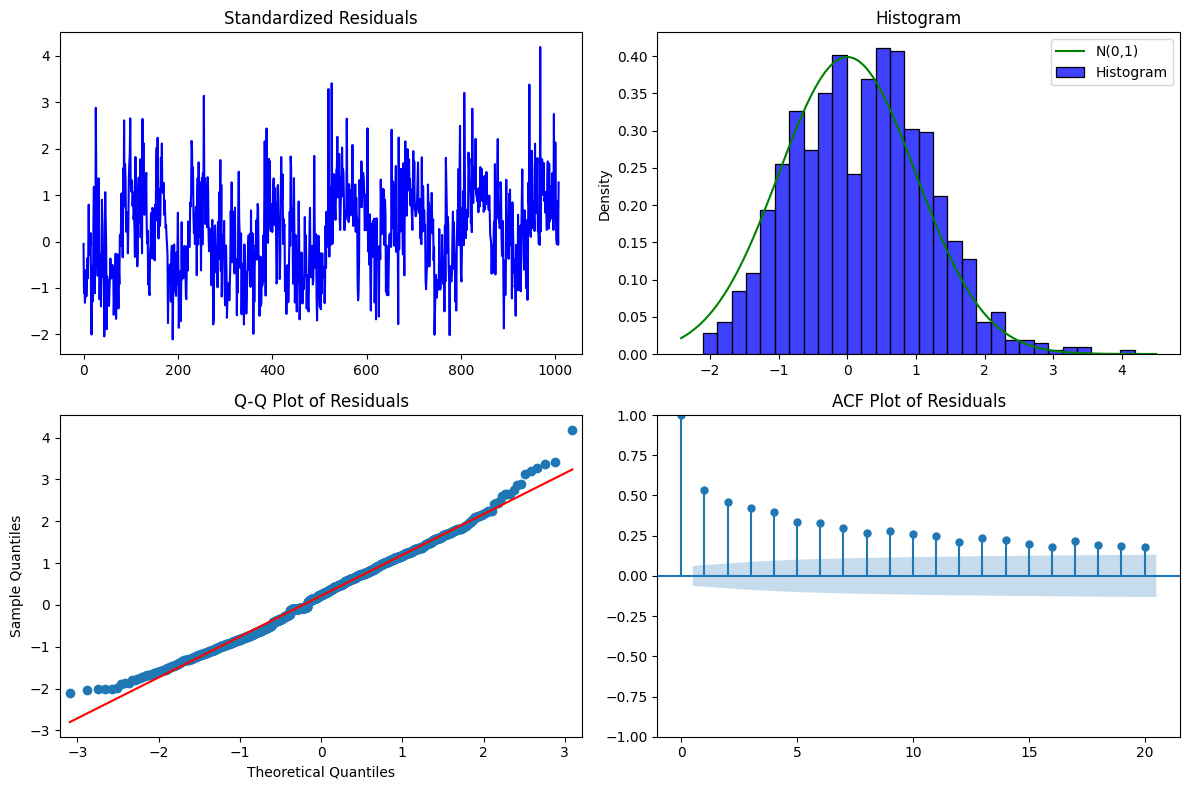

In [98]:
# Se crea gráfica de diagnóstico
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Plot 1: Standardized Residuals
axes[0, 0].plot(range(len(residuals_garch)),residuals_garch, color="blue")
axes[0, 0].set_title("Standardized Residuals")

# Plot 2: Histogram & KDE
sns.histplot(residuals_garch, stat="density", bins=30, kde=False, ax=axes[0, 1], color="blue", label = "Histogram")
xmin, xmax = axes[0, 1].get_xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, 0, 1)  # Normal distribution N(0,1)
axes[0, 1].plot(x, p, 'g-', label = "N(0,1)")
axes[0, 1].set_title("Histogram")
axes[0, 1].legend()

# Plot 3: Q-Q Plot
sm.qqplot(residuals_garch, line="s", ax=axes[1, 0])
axes[1, 0].set_title("Q-Q Plot of Residuals")

# Plot 4: ACF
sm.graphics.tsa.plot_acf(residuals_garch, lags=20, ax=axes[1, 1])
axes[1, 1].set_title("ACF Plot of Residuals")

plt.tight_layout()
plt.show()

### Forecast

In [99]:
# Se calculan los valores predichos del conjunto de validación
yhat_garch  = garch_rolling(train_data['ValorObservado'][-1008:].tolist(), validation_data['ValorObservado'].tolist())

Iteration:      1,   Func. Count:      7,   Neg. LLF: 177189254725792.06
Iteration:      2,   Func. Count:     18,   Neg. LLF: 4959611.762965145
Iteration:      3,   Func. Count:     25,   Neg. LLF: 567223178.1961856
Iteration:      4,   Func. Count:     32,   Neg. LLF: 1413.1179849448747
Iteration:      5,   Func. Count:     39,   Neg. LLF: 934.3938151320949
Iteration:      6,   Func. Count:     46,   Neg. LLF: 978.4250552019296
Iteration:      7,   Func. Count:     54,   Neg. LLF: 915.7929281400696
Iteration:      8,   Func. Count:     61,   Neg. LLF: 912.470620260321
Iteration:      9,   Func. Count:     68,   Neg. LLF: 911.1583278742269
Iteration:     10,   Func. Count:     74,   Neg. LLF: 911.1280892423051
Iteration:     11,   Func. Count:     80,   Neg. LLF: 911.1259962032254
Iteration:     12,   Func. Count:     86,   Neg. LLF: 911.1259034363752
Iteration:     13,   Func. Count:     92,   Neg. LLF: 911.1259024939563
Optimization terminated successfully    (Exit mode 0)
         

In [100]:
# Se calcula el error de predicción del conjunto de validación
forecast_accuracy( np.array(yhat_garch), np.array(validation_data['ValorObservado']), "Value")

,MAE,MAPE,MSE,RMSE
Value,0.78174,0.502595,0.975545,0.987697


In [101]:
# Se calculan los valores predichos del conjunto de test
yhat_garch_test  = garch_rolling(train_data['ValorObservado'][-1008:].tolist(), test_data['ValorObservado'].tolist())

Iteration:      1,   Func. Count:      7,   Neg. LLF: 177189254725792.06
Iteration:      2,   Func. Count:     18,   Neg. LLF: 4959611.762965145
Iteration:      3,   Func. Count:     25,   Neg. LLF: 567223178.1961856
Iteration:      4,   Func. Count:     32,   Neg. LLF: 1413.1179849448747
Iteration:      5,   Func. Count:     39,   Neg. LLF: 934.3938151320949
Iteration:      6,   Func. Count:     46,   Neg. LLF: 978.4250552019296
Iteration:      7,   Func. Count:     54,   Neg. LLF: 915.7929281400696
Iteration:      8,   Func. Count:     61,   Neg. LLF: 912.470620260321
Iteration:      9,   Func. Count:     68,   Neg. LLF: 911.1583278742269
Iteration:     10,   Func. Count:     74,   Neg. LLF: 911.1280892423051
Iteration:     11,   Func. Count:     80,   Neg. LLF: 911.1259962032254
Iteration:     12,   Func. Count:     86,   Neg. LLF: 911.1259034363752
Iteration:     13,   Func. Count:     92,   Neg. LLF: 911.1259024939563
Optimization terminated successfully    (Exit mode 0)
         

In [102]:
# Se calcula el error de predicción del conjunto de test
forecast_accuracy( np.array(yhat_garch_test), np.array(test_data['ValorObservado']), "Value")

,MAE,MAPE,MSE,RMSE
Value,0.823069,0.541742,0.979511,0.989703


### Forecast Plot

In [103]:
# Se calculan los residuales del conjunto de test
residuals_garch_test =  test_data['ValorObservado'] - yhat_garch_test

In [104]:
# Se hace la prueba de Ljung-Box
lb_test = acorr_ljungbox(residuals_garch_test, lags=[144], return_df=True)
print(lb_test)

        lb_stat  lb_pvalue
144  235.082563   0.000002


In [105]:
# Prueba de BDS (Brock-Dechert-Scheinkman)
bds_stat, bds_p_value = bds(residuals_garch_test, max_dim=2, epsilon=None, distance=1.5)
print(f"BDS Statistic: {bds_stat}")
print(f"BDS p-value: {bds_p_value}")

BDS Statistic: 6.166955921480793
BDS p-value: 6.961715336676766e-10


c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a fu

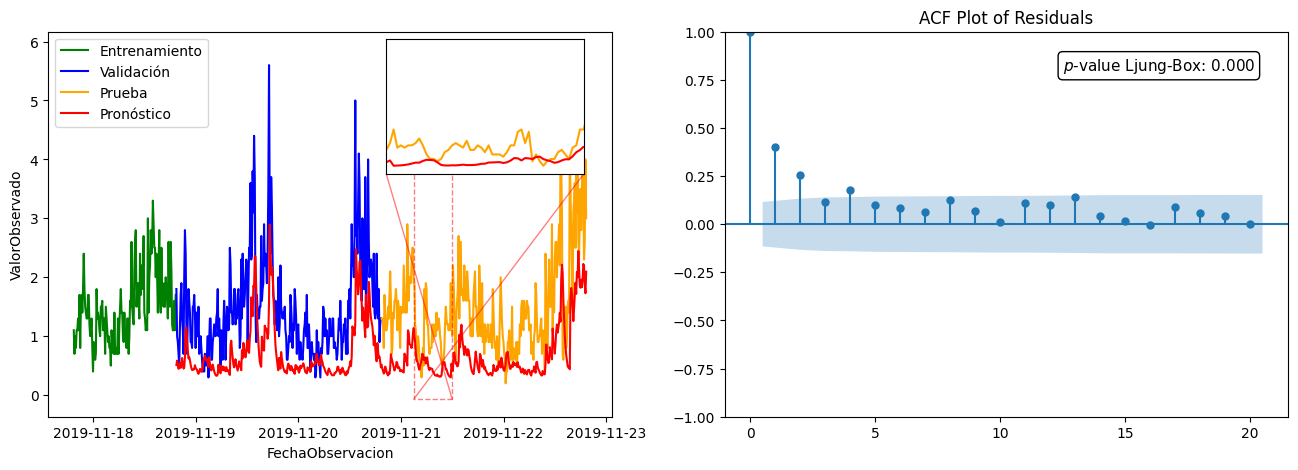

In [106]:
# Gráfica de valores observados vs predicciones
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = sns.lineplot(x=train_data['FechaObservacion'][-144:], y=train_data['ValorObservado'][-144:], label="Entrenamiento", color='g', ax=axes[0])
sns.lineplot(x=validation_data['FechaObservacion'], y=validation_data['ValorObservado'], label="Validación", color='b', ax=axes[0])
sns.lineplot(x=test_data['FechaObservacion'], y=test_data['ValorObservado'], label="Prueba", color='orange', ax=axes[0])
sns.lineplot(x=validation_data['FechaObservacion'], y=yhat_garch, label="Pronóstico", color='r', ax=axes[0])
sns.lineplot(x=test_data['FechaObservacion'], y=yhat_garch_test, color='r', ax=axes[0])

# Se añade gráfica ampliada
#  Se define la posición y tamaño ( [x, y, width, height] cada valor esta entre 0 y 1)
axins = ax.inset_axes([0.6, 0.63, 0.35, 0.35])

# Gráfiga de zona ampliada
sns.lineplot(x=train_data['FechaObservacion'][-288:], y=train_data['ValorObservado'][-288:], color='g', ax=axins)
sns.lineplot(x=validation_data['FechaObservacion'], y=validation_data['ValorObservado'], color='b', ax=axins)
sns.lineplot(x=test_data['FechaObservacion'], y=test_data['ValorObservado'], color='orange', ax=axins)
sns.lineplot(x=validation_data['FechaObservacion'], y=yhat_garch, color='r', ax=axins)
sns.lineplot(x=test_data['FechaObservacion'], y=yhat_garch_test, color='r', ax=axins)

# Se ponen los limites para la zona ampliada
axins.set_xlim(pd.Timestamp('2019-11-21 12:00:00'), pd.Timestamp('2019-11-21 3:00:00'))
ax.indicate_inset_zoom(axins, edgecolor = 'red', lw=1, ls = 'dashed')
axins.set_xticks([])
axins.set_yticks([])
axins.set_xlabel('')
axins.set_ylabel('') 

# ACF Plot
sm.graphics.tsa.plot_acf(residuals_garch_test, lags=20, ax=axes[1] )
p_value = lb_test['lb_pvalue'].values.item()
axes[1].text(0.6, 0.9, f'$p$-value Ljung-Box: {p_value:.3f}', transform=axes[1].transAxes, fontsize=11,
             bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))
axes[1].set_title("ACF Plot of Residuals")

plt.show()


## Preparación de datos modelos de Deep Learning

In [107]:
# Se transforma el valor observado de los datos de entrenamiento a valores entre -1 y 1
scaler = MinMaxScaler(feature_range=(0, 1))
train_data['ScaledValorObservado'] = scaler.fit_transform(np.array(train_data['ValorObservado']).reshape(-1, 1))

C:\Users\luis_\AppData\Local\Temp\ipykernel_20232\1219738599.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['ScaledValorObservado'] = scaler.fit_transform(np.array(train_data['ValorObservado']).reshape(-1, 1))


In [108]:
# Se transforma el valor observado de los datos de validación a valores entre -1 y 1
scaler = MinMaxScaler(feature_range=(0, 1))
validation_data['ScaledValorObservado'] = scaler.fit_transform(np.array(validation_data['ValorObservado']).reshape(-1, 1))

C:\Users\luis_\AppData\Local\Temp\ipykernel_20232\728246351.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  validation_data['ScaledValorObservado'] = scaler.fit_transform(np.array(validation_data['ValorObservado']).reshape(-1, 1))


In [109]:
# Se transforma el valor observado de los datos de prueba a valores entre -1 y 1
scaler = MinMaxScaler(feature_range=(0, 1))
test_data['ScaledValorObservado'] = scaler.fit_transform(np.array(test_data['ValorObservado']).reshape(-1, 1))

C:\Users\luis_\AppData\Local\Temp\ipykernel_20232\260926801.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data['ScaledValorObservado'] = scaler.fit_transform(np.array(test_data['ValorObservado']).reshape(-1, 1))


In [110]:
# Se reestablecen los índices del conjunto de validación, entrenamiento y prueba
train_data.reset_index(drop=True, inplace=True)
validation_data.reset_index(drop=True, inplace=True)
test_data.reset_index(drop=True, inplace=True)

In [111]:
# Función para crear las secuencias de tiempo
def makeXy(ts, nb_timesteps):
    """
    Input: 
           ts: original time series
           nb_timesteps: number of time steps in the regressors
    Output: 
           X: 2-D array of regressors
           y: 1-D array of target 
    """
    X = []
    y = []
    for i in range(nb_timesteps, ts.shape[0]):
        if i-nb_timesteps <= 4:
            print(i-nb_timesteps, i-1, i)
        X.append(list(ts.loc[i-nb_timesteps:i-1])) #Regressors
        y.append(ts.loc[i]) #Target
    X, y = np.array(X), np.array(y)
    return X, y

## 8. Perceptrón multicapa (MLP)

### Selección del modelo

In [112]:
# Se crean las secuencias de tiempo para el conjunto de entrenamiento
X_train, y_train = makeXy(train_data['ScaledValorObservado'], 14)
print('Shape of train arrays:', X_train.shape, y_train.shape)

0 13 14
1 14 15
2 15 16
3 16 17
4 17 18
Shape of train arrays: (383845, 14) (383845,)


In [113]:
# Se crean las secuencias de tiempo para el conjunto de validación
X_val, y_val = makeXy(validation_data['ScaledValorObservado'], 14)
print('Shape of validation arrays:', X_val.shape, y_val.shape)

0 13 14
1 14 15
2 15 16
3 16 17
4 17 18
Shape of validation arrays: (274, 14) (274,)


In [114]:
# Definimos la red MLP
input_layer = Input(shape=(14,), dtype='float32')
dense1 = Dense(32, activation='tanh')(input_layer)
dense2 = Dense(16, activation='tanh')(dense1)
dense3 = Dense(16, activation='tanh')(dense2)
dropout_layer = Dropout(0.2)(dense3)
output_layer = Dense(1, activation='linear')(dropout_layer)

In [115]:
# Resumen del modelo MLP
ts_model = Model(inputs=input_layer, outputs=output_layer)
ts_model.compile(loss='mean_squared_error', optimizer='adam')
ts_model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 14)]              0         
                                                                 
 dense (Dense)               (None, 32)                480       
                                                                 
 dense_1 (Dense)             (None, 16)                528       
                                                                 
 dense_2 (Dense)             (None, 16)                272       
                                                                 
 dropout (Dropout)           (None, 16)                0         
                                                                 
 dense_3 (Dense)             (None, 1)                 17        
                                                                 
Total params: 1,297
Trainable params: 1,297
Non-trainable par

In [116]:
# Función para guardar el modelo para la época en la que la función de pérdida ha sido mínima.
save_weights_at = os.path.join('keras_models', 'wind_speed_MLP_weights14.{epoch:02d}-{val_loss:.4f}.keras')
save_best = ModelCheckpoint(save_weights_at, monitor='val_loss', verbose=0,
                            save_best_only=True, save_weights_only=False, mode='min', save_freq='epoch');

In [ ]:
# Se entrena el modelo, se guarda el mejor
history_wspeed14 = None

if os.path.exists('history_wspeed14.joblib'):
    history_wspeed = load('history_wspeed14.joblib')
    print("El archivo 'history_wspeed14.joblib' ya existe. Se ha cargado el historial del entrenamiento.")
else:
    history_wspeed14 = ts_model.fit(x=X_train, y=y_train, batch_size=16, epochs=20,
             verbose=2, callbacks=[save_best], validation_data=(X_val, y_val),
             shuffle=True);
    dump(history_wspeed14.history, 'history_wspeed14.joblib')
    print("El entrenamiento se ha completado y el historial ha sido guardado en 'history_wspeed14.joblib'.")

Epoch 1/20
23901/23901 - 14s - loss: 2.8519e-04 - val_loss: 0.0180 - 14s/epoch - 583us/step
Epoch 2/20
23901/23901 - 13s - loss: 2.1866e-04 - val_loss: 0.0161 - 13s/epoch - 560us/step
Epoch 3/20
23901/23901 - 14s - loss: 2.0599e-04 - val_loss: 0.0141 - 14s/epoch - 600us/step
Epoch 4/20
23901/23901 - 13s - loss: 2.0684e-04 - val_loss: 0.0135 - 13s/epoch - 541us/step
Epoch 5/20
23901/23901 - 13s - loss: 1.9658e-04 - val_loss: 0.0150 - 13s/epoch - 531us/step
Epoch 6/20
23901/23901 - 13s - loss: 1.9388e-04 - val_loss: 0.0161 - 13s/epoch - 529us/step
Epoch 7/20
23901/23901 - 13s - loss: 1.9605e-04 - val_loss: 0.0149 - 13s/epoch - 532us/step
Epoch 8/20
23901/23901 - 13s - loss: 1.9263e-04 - val_loss: 0.0152 - 13s/epoch - 529us/step
Epoch 9/20
23901/23901 - 13s - loss: 1.9720e-04 - val_loss: 0.0232 - 13s/epoch - 531us/step
Epoch 10/20
23901/23901 - 13s - loss: 1.9062e-04 - val_loss: 0.0152 - 13s/epoch - 531us/step
Epoch 11/20
23901/23901 - 13s - loss: 1.9135e-04 - val_loss: 0.0149 - 13s/epoch

In [117]:
# Se carga el mejor modelo
model_dir = 'keras_models'
files = os.listdir(model_dir)
pattern = r"wind_speed_MLP_weights14\.(\d+)-([\d\.]+)\.keras"

best_val_loss = float('inf')
best_model_file = None
best_model = None

for file in files:
    match = re.match(pattern, file)
    if match:
        epoch = int(match.group(1))
        val_loss = float(match.group(2))
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_file = file

if best_model_file:
    best_model_path = os.path.join(model_dir, best_model_file)
    print(f"Cargando el mejor modelo: {best_model_file} con val_loss: {best_val_loss}")
    best_model = load_model(best_model_path)
else:
    print("No se encontraron archivos de modelos que coincidan con el patrón.")

Cargando el mejor modelo: wind_speed_MLP_weights14.01-0.0276.keras con val_loss: 0.0276


### Gráfica de diagnóstico

In [118]:
# Se calculan las predicciones del mejor modelo en el conjunto entrenamiento para calcular los residuales
preds_mlp_train = best_model.predict(X_train[-1008:])

32/32 [==============================] - 0s 615us/step


In [119]:
# Residuales de modelo seleccionado
residuals_mlp =  X_train[-1008:] - preds_mlp_train
residuals_mlp = residuals_mlp[-1008:,12]

c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


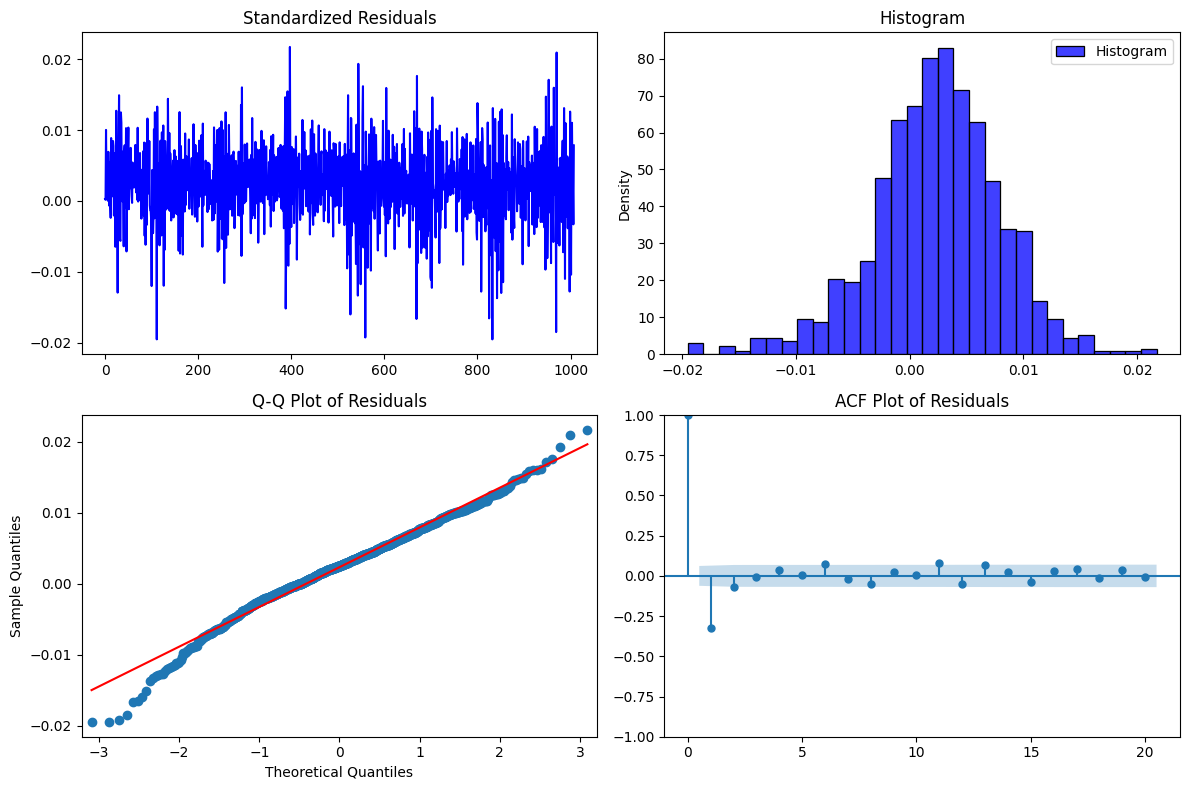

In [120]:
# Se crea gráfica de diagnóstico
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Plot 1: Standardized Residuals
axes[0, 0].plot(range(len(residuals_mlp)),residuals_mlp, color="blue")
axes[0, 0].set_title("Standardized Residuals")

# Plot 2: Histogram & KDE
sns.histplot(residuals_mlp, stat="density", bins=30, kde=False, ax=axes[0, 1], color="blue", label = "Histogram")
xmin, xmax = axes[0, 1].get_xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, 0, 1)  # Normal distribution N(0,1)
axes[0, 1].set_title("Histogram")
axes[0, 1].legend()

# Plot 3: Q-Q Plot
sm.qqplot(residuals_mlp, line="s", ax=axes[1, 0])
axes[1, 0].set_title("Q-Q Plot of Residuals")

# Plot 4: ACF
sm.graphics.tsa.plot_acf(residuals_mlp, lags=20, ax=axes[1, 1])
axes[1, 1].set_title("ACF Plot of Residuals")

plt.tight_layout()
plt.show()

### Forecast

In [121]:
# Se calculan los valores predichos del conjunto de validación
preds = best_model.predict(X_val)
pred_mlp = scaler.inverse_transform(preds)
pred_mlp = np.squeeze(pred_mlp)

9/9 [==============================] - 0s 501us/step


In [122]:
# Se calcula el error de predicción del conjunto de validación
forecast_accuracy(np.array(pred_mlp), np.array(validation_data['ValorObservado'].loc[14:]), "Value")

,MAE,MAPE,MSE,RMSE
Value,0.433698,0.291555,0.386655,0.621816


In [123]:
# Se crean las secuencias de tiempo para el conjunto de test
X_test, y_test = makeXy(test_data['ScaledValorObservado'], 14)

0 13 14
1 14 15
2 15 16
3 16 17
4 17 18


In [124]:
# Se calculan los valores predichos del conjunto de test
preds_test = best_model.predict(X_test)
pred_mlp_test = scaler.inverse_transform(preds_test)
pred_mlp_test = np.squeeze(pred_mlp_test)

9/9 [==============================] - 0s 646us/step


In [125]:
# Se calcula el error de predicción del conjunto de test
forecast_accuracy(np.array(pred_mlp_test), np.array(test_data['ValorObservado'].loc[14:]),  "Value")

,MAE,MAPE,MSE,RMSE
Value,0.404556,0.322825,0.301078,0.548705


### Forecast Plot

In [126]:
# Se calculan los residuales del conjunto de test
residuals_mlp_test =  test_data['ValorObservado'].loc[14:] - pred_mlp_test

In [127]:
# Se hace la prueba de Ljung-Box
lb_test = acorr_ljungbox(residuals_mlp_test, lags=[144], return_df=True)
print(lb_test)

        lb_stat  lb_pvalue
144  156.996825   0.216826


In [128]:
# Prueba de BDS (Brock-Dechert-Scheinkman)
bds_stat, bds_p_value = bds(residuals_mlp_test, max_dim=2, epsilon=None, distance=1.5)
print(f"BDS Statistic: {bds_stat}")
print(f"BDS p-value: {bds_p_value}")

BDS Statistic: 1.2511080594206805
BDS p-value: 0.21089505552728716


c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a fu

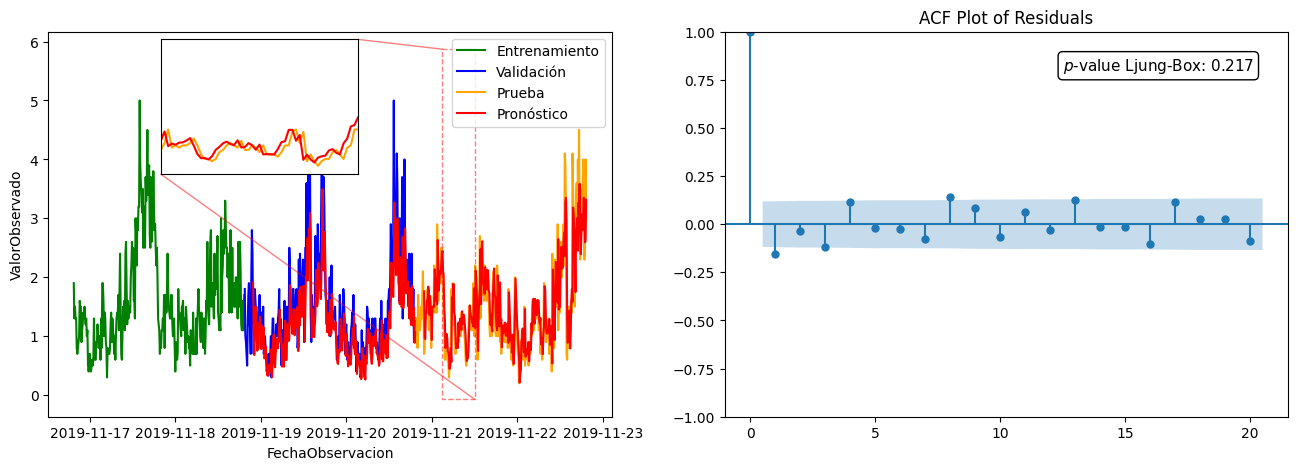

In [129]:
# Gráfica de valores observados vs predicciones
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = sns.lineplot(x=train_data['FechaObservacion'][-288:], y=train_data['ValorObservado'][-288:], label="Entrenamiento", color='g', ax=axes[0])
sns.lineplot(x=validation_data['FechaObservacion'], y=validation_data['ValorObservado'], label="Validación", color='b', ax=axes[0])
sns.lineplot(x=test_data['FechaObservacion'], y=test_data['ValorObservado'], label="Prueba", color='orange', ax=axes[0])
sns.lineplot(x=validation_data['FechaObservacion'].loc[14:], y=pred_mlp, label="Pronóstico", color='r', ax=axes[0])
sns.lineplot(x=test_data['FechaObservacion'].loc[14:], y=pred_mlp_test, color='r', ax=axes[0])

# Se añade gráfica ampliada
#  Se define la posición y tamaño ( [x, y, width, height] cada valor esta entre 0 y 1)
axins = ax.inset_axes([0.2, 0.63, 0.35, 0.35])

# Gráfiga de zona ampliada
sns.lineplot(x=train_data['FechaObservacion'][-288:], y=train_data['ValorObservado'][-288:], color='g', ax=axins)
sns.lineplot(x=validation_data['FechaObservacion'], y=validation_data['ValorObservado'], color='b', ax=axins)
sns.lineplot(x=test_data['FechaObservacion'], y=test_data['ValorObservado'], color='orange', ax=axins)
sns.lineplot(x=validation_data['FechaObservacion'].loc[14:], y=pred_mlp, color='r', ax=axins)
sns.lineplot(x=test_data['FechaObservacion'].loc[14:], y=pred_mlp_test, color='r', ax=axins)

# Se ponen los limites para la zona ampliada
axins.set_xlim(pd.Timestamp('2019-11-21 12:00:00'), pd.Timestamp('2019-11-21 3:00:00'))
ax.indicate_inset_zoom(axins, edgecolor = 'red', lw=1, ls = 'dashed')
axins.set_xticks([])
axins.set_yticks([])
axins.set_xlabel('')
axins.set_ylabel('') 

# ACF Plot
sm.graphics.tsa.plot_acf(residuals_mlp_test, lags=20, ax=axes[1] )
p_value = lb_test['lb_pvalue'].values.item()
axes[1].text(0.6, 0.9, f'$p$-value Ljung-Box: {p_value:.3f}', transform=axes[1].transAxes, fontsize=11,
             bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))
axes[1].set_title("ACF Plot of Residuals")

plt.show()

## 9. Redes Neuronales Recurrentes (RNN)

### Selección de Modelo

In [130]:
# Se crean las secuencias de tiempo para el conjunto de entrenamiento
X_train, y_train = makeXy(train_data['ScaledValorObservado'], 7)

0 6 7
1 7 8
2 8 9
3 9 10
4 10 11


In [131]:
# Se crean las secuencias de tiempo para el conjunto de validación
X_val, y_val = makeXy(validation_data['ScaledValorObservado'], 7)

0 6 7
1 7 8
2 8 9
3 9 10
4 10 11


In [132]:
# Se convierten los datos de entrenamiento y validación en matrices 3D
X_train, X_val = X_train.reshape((X_train.shape[0], X_train.shape[1], 1)), X_val.reshape((X_val.shape[0], X_val.shape[1], 1))
print('Shape of 3D arrays:', X_train.shape, X_val.shape)

Shape of 3D arrays: (383852, 7, 1) (281, 7, 1)


In [133]:
# Definimos la red RRN
input_layer = Input(shape=(14,1), dtype='float32')
RRN_layer1 = SimpleRNN(32, activation='tanh')(input_layer)
dropout_layer = Dropout(0.2)(RRN_layer1)
output_layer = Dense(1, activation='linear')(dropout_layer)

In [134]:
# Resumen del modelo RNN
ts_model = Model(inputs=input_layer, outputs=output_layer)
ts_model.compile(loss='mean_squared_error', optimizer='adam')
ts_model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 14, 1)]           0         
                                                                 
 simple_rnn (SimpleRNN)      (None, 32)                1088      
                                                                 
 dropout_1 (Dropout)         (None, 32)                0         
                                                                 
 dense_4 (Dense)             (None, 1)                 33        
                                                                 
Total params: 1,121
Trainable params: 1,121
Non-trainable params: 0
_________________________________________________________________


In [135]:
# Función para guardar el modelo para la época en la que la función de pérdida ha sido mínima.
save_weights_at = os.path.join('keras_models', 'wind_speed_RNN_weights7.{epoch:02d}-{val_loss:.4f}.keras')
save_best = ModelCheckpoint(save_weights_at, monitor='val_loss', verbose=0,
                            save_best_only=True, save_weights_only=False, mode='min', save_freq='epoch');

In [ ]:
# Se entrena el modelo, se guarda el mejor
history_wspeed7_RNN = None

if os.path.exists('history_wspeed7_RNN.joblib'):
    history_wspeed = load('history_wspeed7_RNN.joblib')
    print("El archivo 'history_wspeed7_RNN.joblib' ya existe. Se ha cargado el historial del entrenamiento.")
else:
    history_wspeed7_RNN = ts_model.fit(x=X_train, y=y_train, batch_size=16, epochs=20,
             verbose=2, callbacks=[save_best], validation_data=(X_val, y_val),
             shuffle=True);
    dump(history_wspeed7_RNN.history, 'history_wspeed7_RNN.joblib')
    print("El entrenamiento se ha completado y el historial ha sido guardado en 'history_wspeed7_RNN.joblib'.")

Epoch 1/20
24009/24009 - 29s - loss: 2.0658e-04 - val_loss: 0.0324 - 29s/epoch - 1ms/step
Epoch 2/20
24009/24009 - 29s - loss: 1.9353e-04 - val_loss: 0.0356 - 29s/epoch - 1ms/step
Epoch 3/20
24009/24009 - 28s - loss: 1.9363e-04 - val_loss: 0.0305 - 28s/epoch - 1ms/step
Epoch 4/20
24009/24009 - 28s - loss: 1.8934e-04 - val_loss: 0.0318 - 28s/epoch - 1ms/step
Epoch 5/20
24009/24009 - 28s - loss: 1.8633e-04 - val_loss: 0.0306 - 28s/epoch - 1ms/step
Epoch 6/20
24009/24009 - 28s - loss: 1.8443e-04 - val_loss: 0.0323 - 28s/epoch - 1ms/step
Epoch 7/20
24009/24009 - 28s - loss: 1.8276e-04 - val_loss: 0.0316 - 28s/epoch - 1ms/step
Epoch 8/20
24009/24009 - 28s - loss: 1.8492e-04 - val_loss: 0.0316 - 28s/epoch - 1ms/step
Epoch 9/20
24009/24009 - 28s - loss: 1.8376e-04 - val_loss: 0.0315 - 28s/epoch - 1ms/step
Epoch 10/20
24009/24009 - 28s - loss: 1.8864e-04 - val_loss: 0.0327 - 28s/epoch - 1ms/step
Epoch 11/20
24009/24009 - 28s - loss: 1.8587e-04 - val_loss: 0.0339 - 28s/epoch - 1ms/step
Epoch 12

In [136]:
# Se carga el mejor modelo
model_dir = 'keras_models'
files = os.listdir(model_dir)
pattern = r"wind_speed_RNN_weights7\.(\d+)-([\d\.]+)\.keras"

best_val_loss = float('inf')
best_model_file = None
best_model = None

for file in files:
    match = re.match(pattern, file)
    if match:
        epoch = int(match.group(1))
        val_loss = float(match.group(2))
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_file = file

if best_model_file:
    best_model_path = os.path.join(model_dir, best_model_file)
    print(f"Cargando el mejor modelo: {best_model_file} con val_loss: {best_val_loss}")
    best_model = load_model(best_model_path)
else:
    print("No se encontraron archivos de modelos que coincidan con el patrón.")

Cargando el mejor modelo: wind_speed_RNN_weights7.19-0.0284.keras con val_loss: 0.0284


### Gráfica de diagnóstico

In [137]:
# Se calculan las predicciones del mejor modelo en el conjunto entrenamiento para calcular los residuales
preds_rnn_train = best_model.predict(X_train[-1008:])

32/32 [==============================] - 0s 758us/step


In [138]:
# Residuales de modelo seleccionado
residuals_rnn =  X_train[-1008:,6] - preds_rnn_train

c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


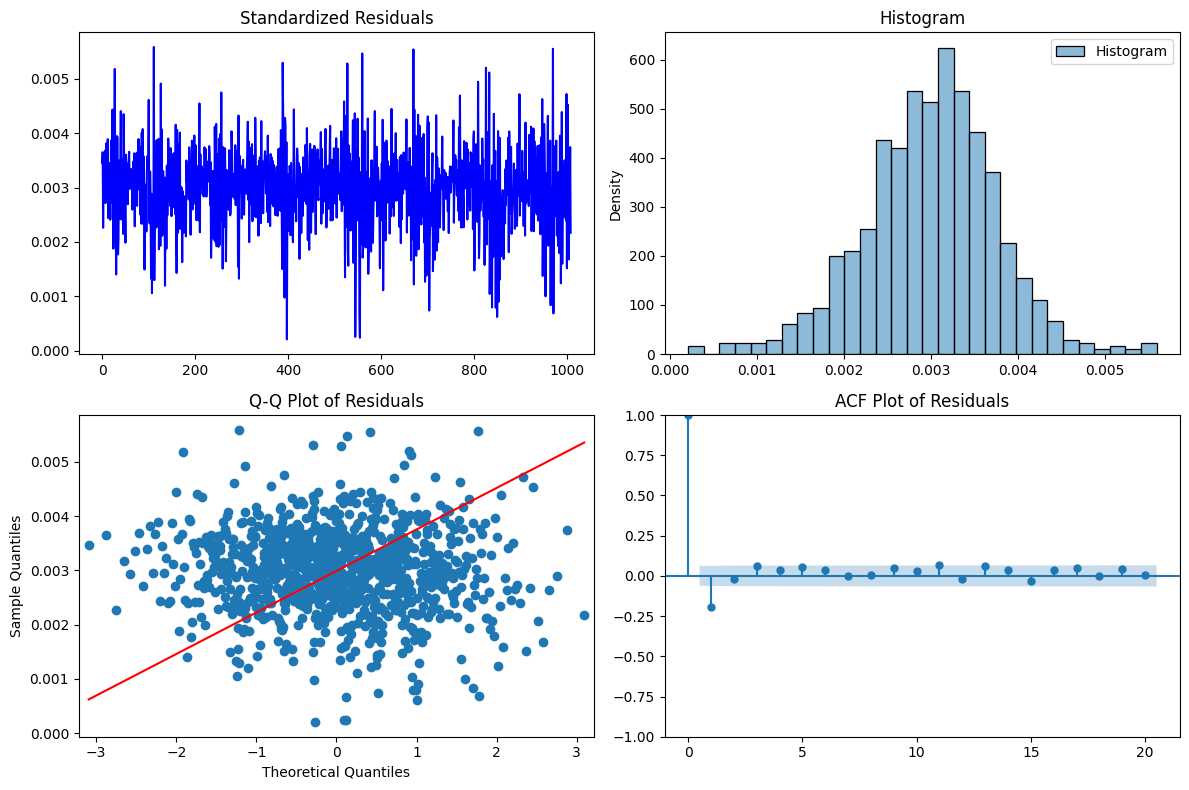

In [139]:
# Se crea gráfica de diagnóstico
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Plot 1: Standardized Residuals
axes[0, 0].plot(range(len(residuals_rnn)),residuals_rnn, color="blue")
axes[0, 0].set_title("Standardized Residuals")

# Plot 2: Histogram & KDE
sns.histplot(residuals_rnn, stat="density", bins=30, kde=False, ax=axes[0, 1], color="blue", label = "Histogram")
xmin, xmax = axes[0, 1].get_xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, 0, 1)  # Normal distribution N(0,1)
axes[0, 1].set_title("Histogram")
axes[0, 1].legend()

# Plot 3: Q-Q Plot
sm.qqplot(residuals_rnn, line="s", ax=axes[1, 0])
axes[1, 0].set_title("Q-Q Plot of Residuals")

# Plot 4: ACF
sm.graphics.tsa.plot_acf(residuals_rnn, lags=20, ax=axes[1, 1])
axes[1, 1].set_title("ACF Plot of Residuals")

plt.tight_layout()
plt.show()

### Forecast

In [140]:
# Se calculan los valores predichos del conjunto de validación
preds = best_model.predict(X_val)
pred_windRNN = scaler.inverse_transform(preds)
pred_windRNN = np.squeeze(pred_windRNN)

9/9 [==============================] - 0s 878us/step


In [141]:
# Se calcula el error de predicción del conjunto de validación
forecast_accuracy( np.array(pred_windRNN), np.array(validation_data['ValorObservado'].loc[7:]), "Value")

,MAE,MAPE,MSE,RMSE
Value,0.477523,0.311156,0.453304,0.673278


In [146]:
# Se crean las secuencias de tiempo para el conjunto de test
X_test, y_test = makeXy(test_data['ScaledValorObservado'], 7)

0 6 7
1 7 8
2 8 9
3 9 10
4 10 11


In [147]:
# Se convierten los datos de test en matrices 3D
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))
print('Shape of 3D arrays:', X_test.shape)

Shape of 3D arrays: (281, 7, 1)


In [148]:
# Se calculan los valores predichos del conjunto de test
preds = best_model.predict(X_test)
pred_windRNN_test = scaler.inverse_transform(preds)
pred_windRNN_test = np.squeeze(pred_windRNN_test)

9/9 [==============================] - 0s 814us/step


In [ ]:
# Se calcula el error de predicción del conjunto de test
forecast_accuracy( np.array(pred_windRNN_test), np.array(test_data['ValorObservado'].loc[7:]), "Value")

,MAE,MAPE,MSE,RMSE
Value,0.390124,0.290227,0.306946,0.554027


### Forecast Plot

In [150]:
# Se calculan los residuales del conjunto de test
residuals_rnn_test =  test_data['ValorObservado'].loc[7:] - pred_windRNN_test

In [151]:
# Se hace la prueba de Ljung-Box
lb_test = acorr_ljungbox(residuals_rnn_test, lags=[144], return_df=True)
print(lb_test)

        lb_stat  lb_pvalue
144  165.842987   0.102744


In [152]:
# Prueba de BDS (Brock-Dechert-Scheinkman)
bds_stat, bds_p_value = bds(residuals_rnn_test, max_dim=2, epsilon=None, distance=1.5)
print(f"BDS Statistic: {bds_stat}")
print(f"BDS p-value: {bds_p_value}")

BDS Statistic: 3.5984251059162284
BDS p-value: 0.0003201500150167466


c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a fu

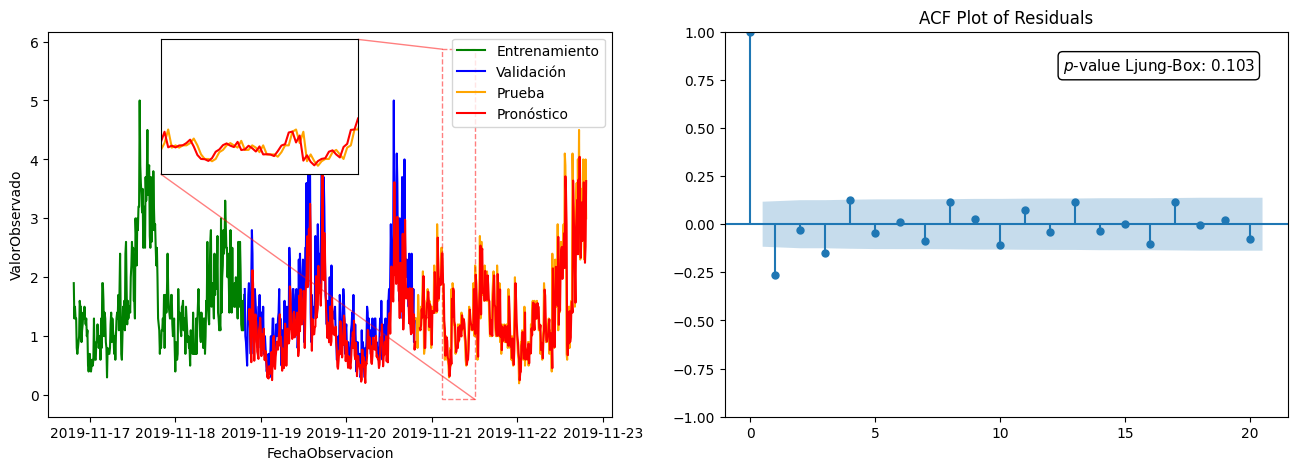

In [153]:
# Gráfica de valores observados vs predicciones
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = sns.lineplot(x=train_data['FechaObservacion'][-288:], y=train_data['ValorObservado'][-288:], label="Entrenamiento", color='g', ax=axes[0])
sns.lineplot(x=validation_data['FechaObservacion'], y=validation_data['ValorObservado'], label="Validación", color='b', ax=axes[0])
sns.lineplot(x=test_data['FechaObservacion'], y=test_data['ValorObservado'], label="Prueba", color='orange', ax=axes[0])
sns.lineplot(x=validation_data['FechaObservacion'].loc[7:], y=pred_windRNN, label="Pronóstico", color='r', ax=axes[0])
sns.lineplot(x=test_data['FechaObservacion'].loc[7:], y=pred_windRNN_test, color='r', ax=axes[0])

# Se añade gráfica ampliada
#  Se define la posición y tamaño ( [x, y, width, height] cada valor esta entre 0 y 1)
axins = ax.inset_axes([0.2, 0.63, 0.35, 0.35])

# Gráfiga de zona ampliada
sns.lineplot(x=train_data['FechaObservacion'][-288:], y=train_data['ValorObservado'][-288:], color='g', ax=axins)
sns.lineplot(x=validation_data['FechaObservacion'], y=validation_data['ValorObservado'], color='b', ax=axins)
sns.lineplot(x=test_data['FechaObservacion'], y=test_data['ValorObservado'], color='orange', ax=axins)
sns.lineplot(x=validation_data['FechaObservacion'].loc[7:], y=pred_windRNN, color='r', ax=axins)
sns.lineplot(x=test_data['FechaObservacion'].loc[7:], y=pred_windRNN_test, color='r', ax=axins)

# Se ponen los limites para la zona ampliada
axins.set_xlim(pd.Timestamp('2019-11-21 12:00:00'), pd.Timestamp('2019-11-21 3:00:00'))
ax.indicate_inset_zoom(axins, edgecolor = 'red', lw=1, ls = 'dashed')
axins.set_xticks([])
axins.set_yticks([])
axins.set_xlabel('')
axins.set_ylabel('') 

# ACF Plot
sm.graphics.tsa.plot_acf(residuals_rnn_test, lags=20, ax=axes[1] )
p_value = 0.103
axes[1].text(0.6, 0.9, f'$p$-value Ljung-Box: {p_value:.3f}', transform=axes[1].transAxes, fontsize=11,
             bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))
axes[1].set_title("ACF Plot of Residuals")

plt.show()


## 10. Red de memoria a largo plazo (LSTM)

### Selección de Modelo

In [154]:
# Se crean las secuencias de tiempo para el conjunto de entrenamiento
X_train, y_train = makeXy(train_data['ScaledValorObservado'], 14)

0 13 14
1 14 15
2 15 16
3 16 17
4 17 18


In [155]:
# Se crean las secuencias de tiempo para el conjunto de validación
X_val, y_val = makeXy(validation_data['ScaledValorObservado'], 14)

0 13 14
1 14 15
2 15 16
3 16 17
4 17 18


In [156]:
# Se convierten los datos de entrenamiento y validación en matrices 3D
X_train, X_val = X_train.reshape((X_train.shape[0], X_train.shape[1], 1)), X_val.reshape((X_val.shape[0], X_val.shape[1], 1))
print('Shape of 3D arrays:', X_train.shape, X_val.shape)

Shape of 3D arrays: (383845, 14, 1) (274, 14, 1)


In [157]:
# Definimos la red LSTM
input_layer = Input(shape=(14,1), dtype='float32')
lstm_layer1 = LSTM(64, input_shape=(14,1), return_sequences=True)(input_layer)
lstm_layer2 = LSTM(32, input_shape=(14,64), return_sequences=False)(lstm_layer1)
dropout_layer = Dropout(0.2)(lstm_layer2)
output_layer = Dense(1, activation='linear')(dropout_layer)

In [158]:
# Resumen del modelo LSTM
ts_model = Model(inputs=input_layer, outputs=output_layer)
ts_model.compile(loss='mean_absolute_error', optimizer='adam') #SGD(lr=0.001, decay=1e-5))
ts_model.summary()

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 14, 1)]           0         
                                                                 
 lstm (LSTM)                 (None, 14, 64)            16896     
                                                                 
 lstm_1 (LSTM)               (None, 32)                12416     
                                                                 
 dropout_2 (Dropout)         (None, 32)                0         
                                                                 
 dense_5 (Dense)             (None, 1)                 33        
                                                                 
Total params: 29,345
Trainable params: 29,345
Non-trainable params: 0
_________________________________________________________________


In [159]:
# Función para guardar el modelo para la época en la que la función de pérdida ha sido mínima.
save_weights_at = os.path.join('keras_models', 'wind_speed_LSTM_weights14.{epoch:02d}-{val_loss:.4f}.keras')
save_best = ModelCheckpoint(save_weights_at, monitor='val_loss', verbose=0,
                            save_best_only=True, save_weights_only=False, mode='min', save_freq='epoch')

In [ ]:
# Se entrena el modelo, se guarda el mejor
history_wspeed14_LSTM = None

if os.path.exists('history_wspeed14_LSTM.joblib'):
    history_wspeed14_LSTM = load('history_wspeed14_LSTM.joblib')
    print("El archivo 'history_wspeed14_LSTM.joblib' ya existe. Se ha cargado el historial del entrenamiento.")
else:
    history_wspeed14_LSTM = ts_model.fit(x=X_train, y=y_train, batch_size=16, epochs=20,
             verbose=2, callbacks=[save_best], validation_data=(X_val, y_val),
             shuffle=True);
    dump(history_wspeed14_LSTM.history, 'history_wspeed14_LSTM.joblib')
    print("El entrenamiento se ha completado y el historial ha sido guardado en 'history_wspeed14_LSTM.joblib'.")

Epoch 1/20
24009/24009 - 115s - loss: 0.0059 - val_loss: 0.1269 - 115s/epoch - 5ms/step
Epoch 2/20
24009/24009 - 118s - loss: 0.0057 - val_loss: 0.1262 - 118s/epoch - 5ms/step
Epoch 3/20
24009/24009 - 125s - loss: 0.0056 - val_loss: 0.1431 - 125s/epoch - 5ms/step
Epoch 4/20
24009/24009 - 118s - loss: 0.0056 - val_loss: 0.1333 - 118s/epoch - 5ms/step
Epoch 5/20
24009/24009 - 129s - loss: 0.0056 - val_loss: 0.1386 - 129s/epoch - 5ms/step
Epoch 6/20
24009/24009 - 120s - loss: 0.0056 - val_loss: 0.1423 - 120s/epoch - 5ms/step
Epoch 7/20
24009/24009 - 126s - loss: 0.0056 - val_loss: 0.1313 - 126s/epoch - 5ms/step
Epoch 8/20
24009/24009 - 120s - loss: 0.0056 - val_loss: 0.1390 - 120s/epoch - 5ms/step
Epoch 9/20
24009/24009 - 113s - loss: 0.0056 - val_loss: 0.1348 - 113s/epoch - 5ms/step
Epoch 10/20
24009/24009 - 107s - loss: 0.0056 - val_loss: 0.1258 - 107s/epoch - 4ms/step
Epoch 11/20
24009/24009 - 107s - loss: 0.0055 - val_loss: 0.1311 - 107s/epoch - 4ms/step
Epoch 12/20
24009/24009 - 107s

In [160]:
# Se carga el mejor modelo
model_dir = 'keras_models'
files = os.listdir(model_dir)
pattern = r"wind_speed_LSTM_weights14\.(\d+)-([\d\.]+)\.keras"
    
best_val_loss = float('inf')
best_model_file = None
best_model = None

for file in files:
    match = re.match(pattern, file)
    if match:
        epoch = int(match.group(1))
        val_loss = float(match.group(2))
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_file = file

if best_model_file:
    best_model_path = os.path.join(model_dir, best_model_file)
    print(f"Cargando el mejor modelo: {best_model_file} con val_loss: {best_val_loss}")
    best_model = load_model(best_model_path)
else:
    print("No se encontraron archivos de modelos que coincidan con el patrón.")

Cargando el mejor modelo: wind_speed_LSTM_weights14.10-0.1258.keras con val_loss: 0.1258


### Gráfica de diagnóstico

In [161]:
# Se calculan las predicciones del mejor modelo en el conjunto entrenamiento para calcular los residuales
preds_lstm_train = best_model.predict(X_train[-1008:])

32/32 [==============================] - 0s 2ms/step


In [162]:
# Residuales de modelo seleccionado
residuals_lstm =  X_train[-1008:,12] - preds_lstm_train

c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


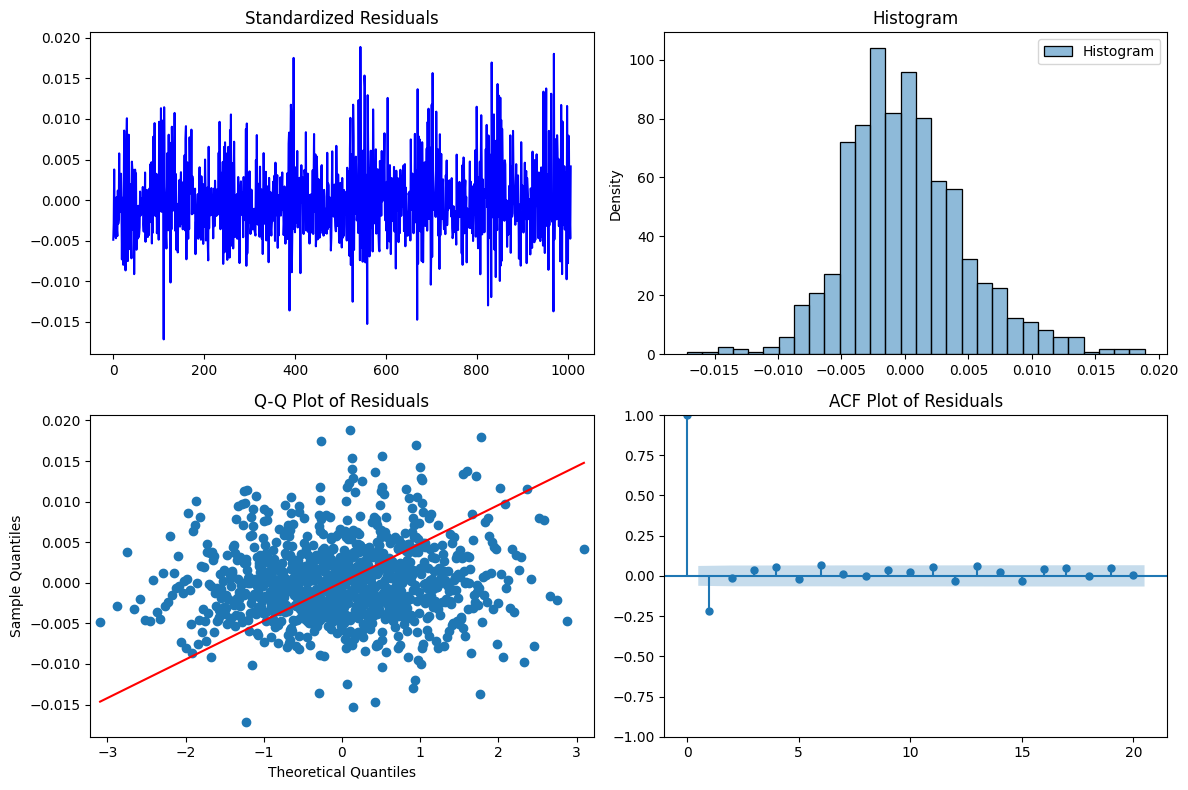

In [163]:
# Se crea gráfica de diagnóstico
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Plot 1: Standardized Residuals
axes[0, 0].plot(range(len(residuals_lstm)),residuals_lstm, color="blue")
axes[0, 0].set_title("Standardized Residuals")

# Plot 2: Histogram & KDE
sns.histplot(residuals_lstm, stat="density", bins=30, kde=False, ax=axes[0, 1], color="blue", label = "Histogram")
xmin, xmax = axes[0, 1].get_xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, 0, 1)  # Normal distribution N(0,1)
axes[0, 1].set_title("Histogram")
axes[0, 1].legend()

# Plot 3: Q-Q Plot
sm.qqplot(residuals_lstm, line="s", ax=axes[1, 0])
axes[1, 0].set_title("Q-Q Plot of Residuals")

# Plot 4: ACF
sm.graphics.tsa.plot_acf(residuals_lstm, lags=20, ax=axes[1, 1])
axes[1, 1].set_title("ACF Plot of Residuals")

plt.tight_layout()
plt.show()

### Forecast

In [164]:
# Se calculan los valores predichos del conjunto de validación
preds = best_model.predict(X_val)
pred_windLSTM = scaler.inverse_transform(preds)
pred_windLSTM = np.squeeze(pred_windLSTM)

9/9 [==============================] - 0s 2ms/step


In [165]:
# Se calcula el error de predicción del conjunto de validación
forecast_accuracy( np.array(pred_windLSTM), np.array(validation_data['ValorObservado'].loc[14:]), "Value")

,MAE,MAPE,MSE,RMSE
Value,0.509195,0.327001,0.502548,0.708906


In [166]:
# Se crean las secuencias de tiempo para el conjunto de test
X_test, y_test = makeXy(test_data['ScaledValorObservado'], 14)

0 13 14
1 14 15
2 15 16
3 16 17
4 17 18


In [167]:
# Se convierten los datos de test en matrices 3D
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))
print('Shape of 3D arrays:', X_test.shape)

Shape of 3D arrays: (274, 14, 1)


In [168]:
# Se calculan los valores predichos del conjunto de test
preds = best_model.predict(X_test)
pred_windLSTM_test = scaler.inverse_transform(preds)
pred_windLSTM_test = np.squeeze(pred_windLSTM_test)

1/9 [==>...........................] - ETA: 0s

9/9 [==============================] - 0s 2ms/step


In [169]:
# Se calcula el error de predicción del conjunto de test
forecast_accuracy( np.array(pred_windLSTM_test), np.array(test_data['ValorObservado'].loc[14:]), "Value")

,MAE,MAPE,MSE,RMSE
Value,0.394159,0.280169,0.325755,0.57075


### Forecast Plot

In [170]:
# Se calculan los residuales del conjunto de test
residuals_lstm_test =  test_data['ValorObservado'].loc[14:] - pred_windLSTM_test

In [171]:
# Se hace la prueba de Ljung-Box
lb_test = acorr_ljungbox(residuals_lstm_test, lags=[144], return_df=True)
print(lb_test)

        lb_stat  lb_pvalue
144  163.167422   0.130978


In [172]:
# Prueba de BDS (Brock-Dechert-Scheinkman)
bds_stat, bds_p_value = bds(residuals_lstm_test, max_dim=2, epsilon=None, distance=1.5)
print(f"BDS Statistic: {bds_stat}")
print(f"BDS p-value: {bds_p_value}")

BDS Statistic: 2.872064420774621
BDS p-value: 0.004077998268359312


c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a fu

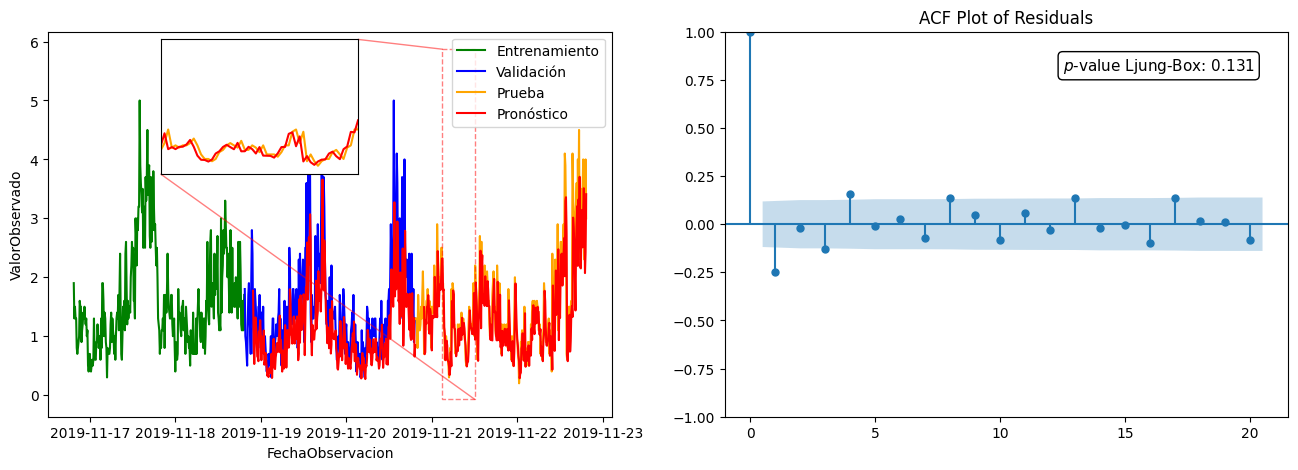

In [173]:
# Gráfica de valores observados vs predicciones
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = sns.lineplot(x=train_data['FechaObservacion'][-288:], y=train_data['ValorObservado'][-288:], label="Entrenamiento", color='g', ax=axes[0])
sns.lineplot(x=validation_data['FechaObservacion'], y=validation_data['ValorObservado'], label="Validación", color='b', ax=axes[0])
sns.lineplot(x=test_data['FechaObservacion'], y=test_data['ValorObservado'], label="Prueba", color='orange', ax=axes[0])
sns.lineplot(x=validation_data['FechaObservacion'].loc[14:], y=pred_windLSTM, label="Pronóstico", color='r', ax=axes[0])
sns.lineplot(x=test_data['FechaObservacion'].loc[14:], y=pred_windLSTM_test, color='r', ax=axes[0])

# Se añade gráfica ampliada
#  Se define la posición y tamaño ( [x, y, width, height] cada valor esta entre 0 y 1)
axins = ax.inset_axes([0.2, 0.63, 0.35, 0.35])

# Gráfiga de zona ampliada
sns.lineplot(x=train_data['FechaObservacion'][-288:], y=train_data['ValorObservado'][-288:], color='g', ax=axins)
sns.lineplot(x=validation_data['FechaObservacion'], y=validation_data['ValorObservado'], color='b', ax=axins)
sns.lineplot(x=test_data['FechaObservacion'], y=test_data['ValorObservado'], color='orange', ax=axins)
sns.lineplot(x=validation_data['FechaObservacion'].loc[14:], y=pred_windLSTM, color='r', ax=axins)
sns.lineplot(x=test_data['FechaObservacion'].loc[14:], y=pred_windLSTM_test, color='r', ax=axins)

# Se ponen los limites para la zona ampliada
axins.set_xlim(pd.Timestamp('2019-11-21 12:00:00'), pd.Timestamp('2019-11-21 3:00:00'))
ax.indicate_inset_zoom(axins, edgecolor = 'red', lw=1, ls = 'dashed')
axins.set_xticks([])
axins.set_yticks([])
axins.set_xlabel('')
axins.set_ylabel('') 

# ACF Plot
sm.graphics.tsa.plot_acf(residuals_lstm_test, lags=20, ax=axes[1] )
p_value =  0.131
axes[1].text(0.6, 0.9, f'$p$-value Ljung-Box: {p_value:.3f}', transform=axes[1].transAxes, fontsize=11,
             bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))
axes[1].set_title("ACF Plot of Residuals")

plt.show()

## Original model - A-BILSTM

### Selección de Modelo

In [174]:
# Se crean las secuencias de tiempo para el conjunto de entrenamiento
X_train, y_train = makeXy(train_data['ScaledValorObservado'], 14)

0 13 14
1 14 15
2 15 16
3 16 17
4 17 18


In [175]:
# Se crean las secuencias de tiempo para el conjunto de validación
X_val, y_val = makeXy(validation_data['ScaledValorObservado'], 14)

0 13 14
1 14 15
2 15 16
3 16 17
4 17 18


In [176]:
# Se convierten los datos de entrenamiento y validación en matrices 3D
X_train, X_val = X_train.reshape((X_train.shape[0], X_train.shape[1], 1)), X_val.reshape((X_val.shape[0], X_val.shape[1], 1))
print('Shape of 3D arrays:', X_train.shape, X_val.shape)

Shape of 3D arrays: (383845, 14, 1) (274, 14, 1)


In [177]:
# Definimos la red A-BILSTM
input_layer = Input(shape=(14, 1))
bi_lstm_out = Bidirectional(LSTM(64, input_shape = (14,1), return_sequences=True))(input_layer)

# Mecanismo de atención
query = Dense(128)(bi_lstm_out)  # Query de las salidas de LSTM
key = Dense(128)(bi_lstm_out)    # Key de las salidas de LSTM
attention = Attention()([query, key])  # Se calculan los puntajes de atención

# Aplica pesos de atención a las salidas de BILSTM
attention_out = Multiply()([bi_lstm_out, attention])

dense_out = Dense(32, activation="relu")(attention_out[:, -1, :])  # Select last time step
dropout_layer = Dropout(0.2)(dense_out)
output_layer = Dense(1)(dropout_layer) 

In [178]:
# Resumen del modelo A-BILSTM
model = Model(inputs=input_layer, outputs=output_layer)
model.compile(optimizer="adam", loss="mean_absolute_error")
model.summary()

Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_4 (InputLayer)           [(None, 14, 1)]      0           []                               
                                                                                                  
 bidirectional (Bidirectional)  (None, 14, 128)      33792       ['input_4[0][0]']                
                                                                                                  
 dense_6 (Dense)                (None, 14, 128)      16512       ['bidirectional[0][0]']          
                                                                                                  
 dense_7 (Dense)                (None, 14, 128)      16512       ['bidirectional[0][0]']          
                                                                                            

In [179]:
# Función para guardar el modelo para la época en la que la función de pérdida ha sido mínima.
save_weights_at = os.path.join('keras_models', 'wind_speed_AttBiLSTM_weights14.{epoch:02d}-{val_loss:.4f}.keras')
save_best = ModelCheckpoint(save_weights_at, monitor='val_loss', verbose=0,
                            save_best_only=True, save_weights_only=False, mode='min', save_freq='epoch')

In [ ]:
# Se entrena el modelo, se guarda el mejor
history_wspeed14_AttBiLSTM = None

if os.path.exists('history_wspeed14_AttBiLSTM.joblib'):
    history_wspeed14_AttBiLSTM = load('history_wspeed14_AttBiLSTM.joblib')
    print("El archivo 'history_wspeed14_AttBiLSTM.joblib' ya existe. Se ha cargado el historial del entrenamiento.")
else:
    history_wspeed14_AttBiLSTM = model.fit(x=X_train, y=y_train, batch_size=16, epochs=5,
             verbose=2, callbacks=[save_best], validation_data=(X_val, y_val),
             shuffle=True);
    dump(history_wspeed14_AttBiLSTM.history, 'history_wspeed14_AttBiLSTM.joblib')
    print("El entrenamiento se ha completado y el historial ha sido guardado en 'history_wspeed14_AttBiLSTM.joblib'.")

Epoch 1/5
23991/23991 - 108s - loss: 0.0072 - val_loss: 0.1224 - 108s/epoch - 4ms/step
Epoch 2/5
23991/23991 - 87s - loss: 0.0037 - val_loss: 0.1223 - 87s/epoch - 4ms/step
Epoch 3/5
23991/23991 - 102s - loss: 0.0037 - val_loss: 0.1226 - 102s/epoch - 4ms/step
Epoch 4/5
23991/23991 - 101s - loss: 0.0037 - val_loss: 0.1225 - 101s/epoch - 4ms/step
Epoch 5/5
23991/23991 - 101s - loss: 0.0037 - val_loss: 0.1231 - 101s/epoch - 4ms/step
El entrenamiento se ha completado y el historial ha sido guardado en 'history_wspeed14_5_AttBiLSTM.joblib'.


In [180]:
# Se carga el mejor modelo
model_dir = 'keras_models'
files = os.listdir(model_dir)
pattern = r"wind_speed_AttBiLSTM_weights14\.(\d+)-([\d\.]+)\.keras"
    
best_val_loss = float('inf')
best_model_file = None
best_model = None

for file in files:
    match = re.match(pattern, file)
    if match:
        epoch = int(match.group(1))
        val_loss = float(match.group(2))
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_file = file

if best_model_file:
    best_model_path = os.path.join(model_dir, best_model_file)
    print(f"Cargando el mejor modelo: {best_model_file} con val_loss: {best_val_loss}")
    best_model = load_model(best_model_path)
else:
    print("No se encontraron archivos de modelos que coincidan con el patrón.")

Cargando el mejor modelo: wind_speed_AttBiLSTM_weights14.02-0.0774.keras con val_loss: 0.0774


### Gráfica de diagnóstico

In [181]:
# Se calculan las predicciones del mejor modelo en el conjunto entrenamiento para calcular los residuales
preds_bilstm_train = best_model.predict(X_train[-1008:])

32/32 [==============================] - 0s 2ms/step


In [182]:
# Residuales de modelo seleccionado
residuals_bilstm = X_train[-1008:,12] - preds_bilstm_train

c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


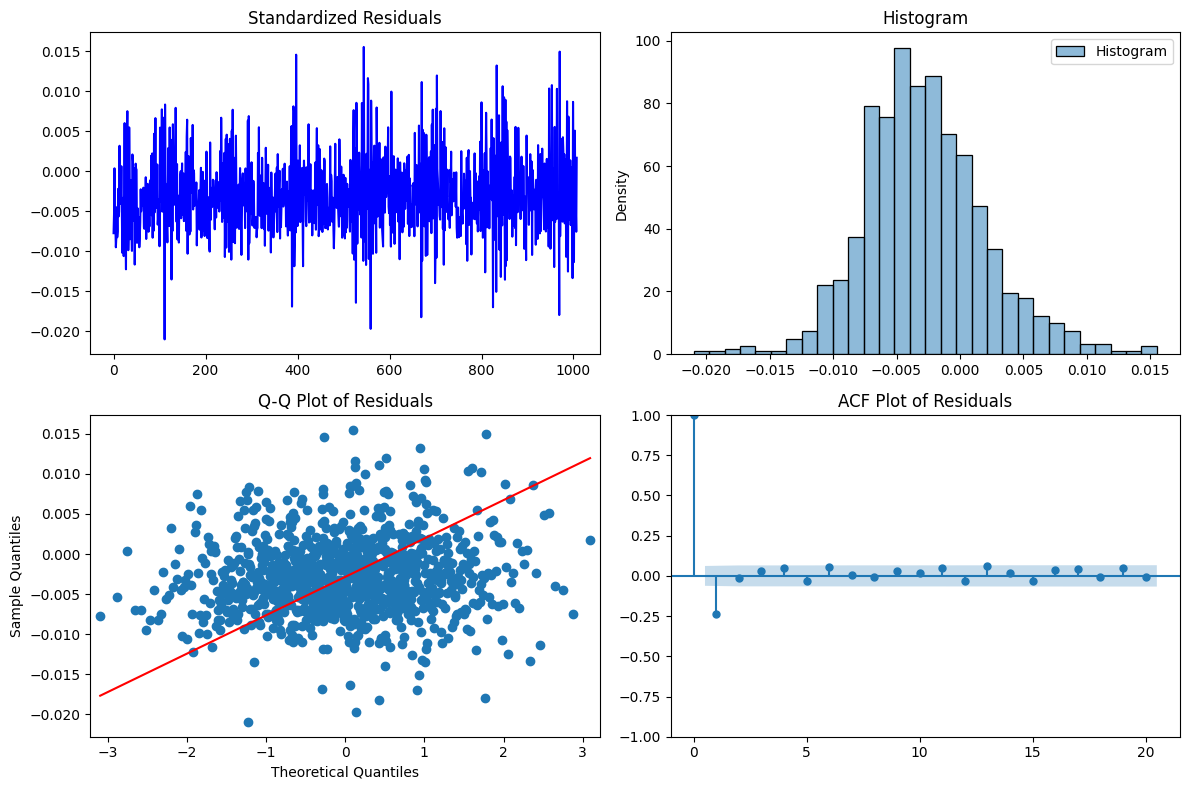

In [183]:
# Se crea gráfica de diagnóstico
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Plot 1: Standardized Residuals
axes[0, 0].plot(range(len(residuals_bilstm)),residuals_bilstm, color="blue")
axes[0, 0].set_title("Standardized Residuals")

# Plot 2: Histogram & KDE
sns.histplot(residuals_bilstm, stat="density", bins=30, kde=False, ax=axes[0, 1], color="blue", label = "Histogram")
xmin, xmax = axes[0, 1].get_xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, 0, 1)  # Normal distribution N(0,1)
axes[0, 1].set_title("Histogram")
axes[0, 1].legend()

# Plot 3: Q-Q Plot
sm.qqplot(residuals_bilstm, line="s", ax=axes[1, 0])
axes[1, 0].set_title("Q-Q Plot of Residuals")

# Plot 4: ACF
sm.graphics.tsa.plot_acf(residuals_bilstm, lags=20, ax=axes[1, 1])
axes[1, 1].set_title("ACF Plot of Residuals")

plt.tight_layout()
plt.show()

### Forecast

In [184]:
# Se calculan los valores predichos del conjunto de validación
preds = best_model.predict(X_val)
pred_windAttBiLSTM = scaler.inverse_transform(preds)
pred_windAttBiLSTM = np.squeeze(pred_windAttBiLSTM)

9/9 [==============================] - 0s 749us/step


In [185]:
# Se calcula el error de predicción del conjunto de validación
forecast_accuracy( np.array(pred_windAttBiLSTM), np.array(validation_data['ValorObservado'].loc[14:]), "Value")

,MAE,MAPE,MSE,RMSE
Value,0.486838,0.312003,0.4761,0.69


In [186]:
# Se crean las secuencias de tiempo para el conjunto de test
X_test, y_test = makeXy(test_data['ScaledValorObservado'], 14)

0 13 14
1 14 15
2 15 16
3 16 17
4 17 18


In [187]:
# Se convierten los datos de entrenamiento y validación en matrices 3D
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))
print('Shape of 3D arrays:', X_train.shape)

Shape of 3D arrays: (383845, 14, 1)


In [188]:
# Se calculan los valores predichos del conjunto de test
preds = best_model.predict(X_test)
pred_windAttBiLSTM_test = scaler.inverse_transform(preds)
pred_windAttBiLSTM_test = np.squeeze(pred_windAttBiLSTM_test)

9/9 [==============================] - 0s 625us/step


In [189]:
# Se calcula el error de predicción del conjunto de test
forecast_accuracy( np.array(pred_windAttBiLSTM_test), np.array(test_data['ValorObservado'].loc[14:]), "Value")

,MAE,MAPE,MSE,RMSE
Value,0.382225,0.276724,0.307334,0.554377


### Forecast Plot

In [190]:
# Se calculan los residuales del conjunto de test
residuals_AttBiLSTM_test =  test_data['ValorObservado'].loc[14:] - pred_windAttBiLSTM_test

In [191]:
# Se hace la prueba de Ljung-Box
lb_test = acorr_ljungbox(residuals_AttBiLSTM_test, lags=[144], return_df=True)
print(lb_test)

        lb_stat  lb_pvalue
144  147.993575   0.392661


In [192]:
# Prueba de BDS (Brock-Dechert-Scheinkman)
bds_stat, bds_p_value = bds(residuals_AttBiLSTM_test, max_dim=2, epsilon=None, distance=1.5)
print(f"BDS Statistic: {bds_stat}")
print(f"BDS p-value: {bds_p_value}")

BDS Statistic: 2.179290826760344
BDS p-value: 0.02931007025181864


c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a fu

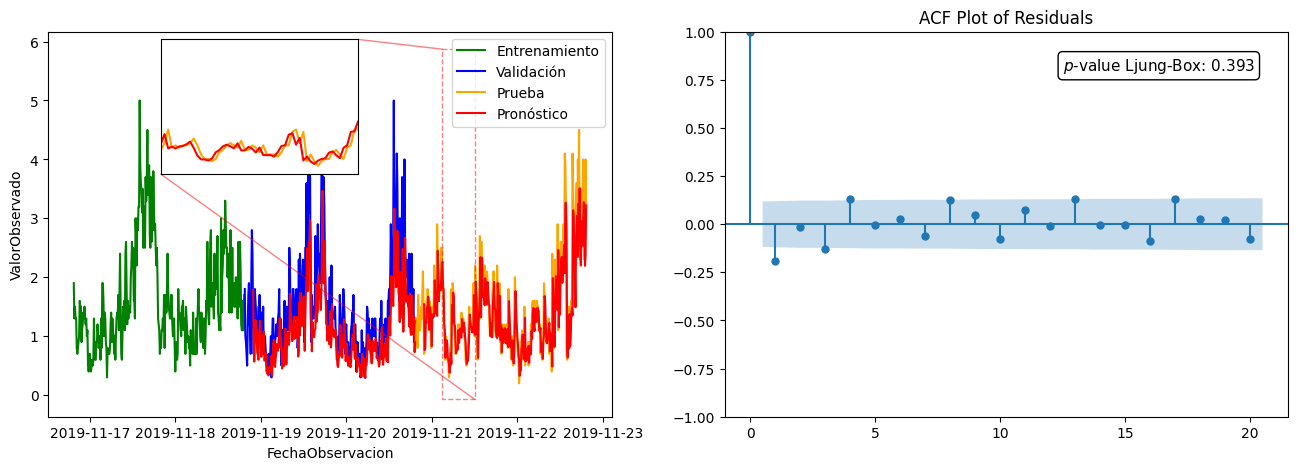

In [193]:
# Gráfica de valores observados vs predicciones
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = sns.lineplot(x=train_data['FechaObservacion'][-288:], y=train_data['ValorObservado'][-288:], label="Entrenamiento", color='g', ax=axes[0])
sns.lineplot(x=validation_data['FechaObservacion'], y=validation_data['ValorObservado'], label="Validación", color='b', ax=axes[0])
sns.lineplot(x=test_data['FechaObservacion'], y=test_data['ValorObservado'], label="Prueba", color='orange', ax=axes[0])
sns.lineplot(x=validation_data['FechaObservacion'].loc[14:], y=pred_windAttBiLSTM, label="Pronóstico", color='r', ax=axes[0])
sns.lineplot(x=test_data['FechaObservacion'].loc[14:], y=pred_windAttBiLSTM_test, color='r', ax=axes[0])

# Se añade gráfica ampliada
#  Se define la posición y tamaño ( [x, y, width, height] cada valor esta entre 0 y 1)
axins = ax.inset_axes([0.2, 0.63, 0.35, 0.35])

# Gráfiga de zona ampliada
sns.lineplot(x=train_data['FechaObservacion'][-288:], y=train_data['ValorObservado'][-288:], color='g', ax=axins)
sns.lineplot(x=validation_data['FechaObservacion'], y=validation_data['ValorObservado'], color='b', ax=axins)
sns.lineplot(x=test_data['FechaObservacion'], y=test_data['ValorObservado'], color='orange', ax=axins)
sns.lineplot(x=validation_data['FechaObservacion'].loc[14:], y=pred_windAttBiLSTM, color='r', ax=axins)
sns.lineplot(x=test_data['FechaObservacion'].loc[14:], y=pred_windAttBiLSTM_test, color='r', ax=axins)

# Se ponen los limites para la zona ampliada
axins.set_xlim(pd.Timestamp('2019-11-21 12:00:00'), pd.Timestamp('2019-11-21 3:00:00'))
ax.indicate_inset_zoom(axins, edgecolor = 'red', lw=1, ls = 'dashed')
axins.set_xticks([])
axins.set_yticks([])
axins.set_xlabel('')
axins.set_ylabel('') 

# ACF Plot
sm.graphics.tsa.plot_acf(residuals_AttBiLSTM_test, lags=20, ax=axes[1] )
p_value =  lb_test['lb_pvalue'].values.item()
axes[1].text(0.6, 0.9, f'$p$-value Ljung-Box: {p_value:.3f}', transform=axes[1].transAxes, fontsize=11,
             bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))
axes[1].set_title("ACF Plot of Residuals")

plt.show()

## Comparación de modelos

c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\luis_\miniconda3\envs\ml_venv\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a fu

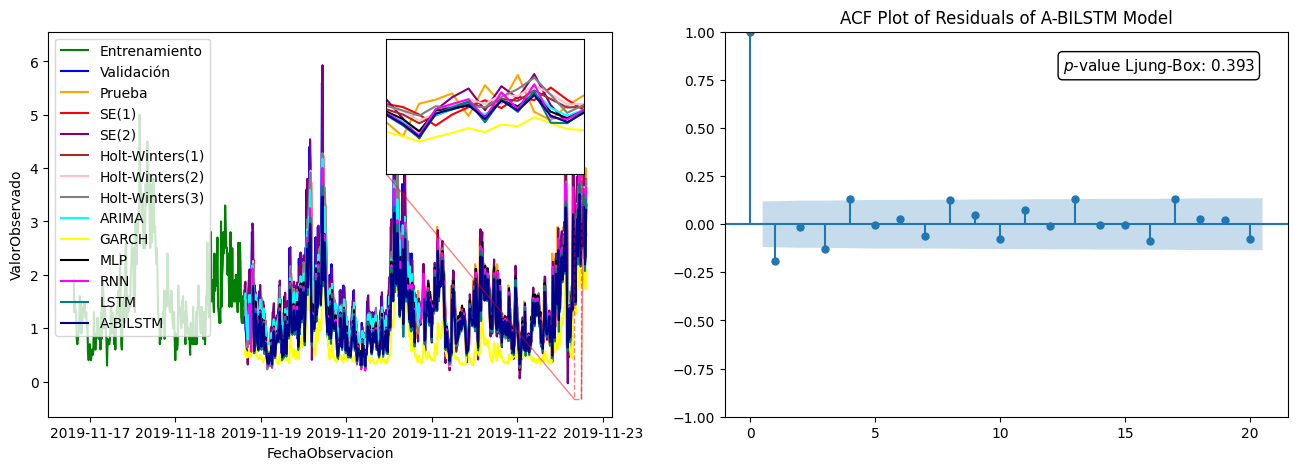

In [194]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfica de valores observados vs predicciones
ax = sns.lineplot(x=train_data['FechaObservacion'][-288:], y=train_data['ValorObservado'][-288:], label="Entrenamiento", color='g', ax=axes[0])
sns.lineplot(x=validation_data['FechaObservacion'], y=validation_data['ValorObservado'], label="Validación", color='b', ax=axes[0])
sns.lineplot(x=test_data['FechaObservacion'], y=test_data['ValorObservado'], label="Prueba", color='orange', ax=axes[0])

#ES1
sns.lineplot(x=validation_data['FechaObservacion'], y=yhat_expsmoth1, label="SE(1)", color='r', ax=axes[0])
sns.lineplot(x=test_data['FechaObservacion'], y=yhat_expsmoth1_test, color='r', ax=axes[0])

#ES2
sns.lineplot(x=validation_data['FechaObservacion'], y=yhat_expsmoth2, label="SE(2)", color='purple', ax=axes[0])
sns.lineplot(x=test_data['FechaObservacion'], y=yhat_expsmoth2_test, color='purple', ax=axes[0])

#HW1
sns.lineplot(x=validation_data['FechaObservacion'], y=yhat_hw1, label="Holt-Winters(1)", color='brown', ax=axes[0])
sns.lineplot(x=test_data['FechaObservacion'], y=yhat_hw1_test, color='brown', ax=axes[0])

#HW2
sns.lineplot(x=validation_data['FechaObservacion'], y=yhat_hw2, label="Holt-Winters(2)", color='pink', ax=axes[0])
sns.lineplot(x=test_data['FechaObservacion'], y=yhat_hw2_test, color='pink', ax=axes[0])

#HW3
sns.lineplot(x=validation_data['FechaObservacion'], y=yhat_hw3, label="Holt-Winters(3)", color='gray', ax=axes[0])
sns.lineplot(x=test_data['FechaObservacion'], y=yhat_hw3_test, color='gray', ax=axes[0])

#ARIMA
sns.lineplot(x=validation_data['FechaObservacion'], y=yhat_arima, label="ARIMA", color='cyan', ax=axes[0])
sns.lineplot(x=test_data['FechaObservacion'], y=yhat_arima_test, color='cyan', ax=axes[0])

#GARCH
sns.lineplot(x=validation_data['FechaObservacion'], y=yhat_garch, label="GARCH", color='yellow', ax=axes[0])
sns.lineplot(x=test_data['FechaObservacion'], y=yhat_garch_test, color='yellow', ax=axes[0])

#MLP
sns.lineplot(x=validation_data['FechaObservacion'].loc[14:], y=pred_mlp, label="MLP", color='black', ax=axes[0])
sns.lineplot(x=test_data['FechaObservacion'].loc[14:], y=pred_mlp_test, color='black', ax=axes[0])

#RNN
sns.lineplot(x=validation_data['FechaObservacion'].loc[7:], y=pred_windRNN, label="RNN", color='magenta', ax=axes[0])
sns.lineplot(x=test_data['FechaObservacion'].loc[7:], y=pred_windRNN_test, color='magenta', ax=axes[0])

#LSTM
sns.lineplot(x=validation_data['FechaObservacion'].loc[14:], y=pred_windLSTM, label="LSTM", color='teal', ax=axes[0])
sns.lineplot(x=test_data['FechaObservacion'].loc[14:], y=pred_windLSTM_test, color='teal', ax=axes[0])

#A-BILSTM
sns.lineplot(x=validation_data['FechaObservacion'].loc[14:], y=pred_windAttBiLSTM, label="A-BILSTM", color='darkblue', ax=axes[0])
sns.lineplot(x=test_data['FechaObservacion'].loc[14:], y=pred_windAttBiLSTM_test, color='darkblue', ax=axes[0])

# Se añade gráfica ampliada
#  Se define la posición y tamaño ( [x, y, width, height] cada valor esta entre 0 y 1)
axins = ax.inset_axes([0.6, 0.63, 0.35, 0.35])

# Gráfiga de zona ampliada
sns.lineplot(x=train_data['FechaObservacion'][-288:], y=train_data['ValorObservado'][-288:], color='g', ax=axins)
sns.lineplot(x=validation_data['FechaObservacion'], y=validation_data['ValorObservado'], color='b', ax=axins)
sns.lineplot(x=test_data['FechaObservacion'], y=test_data['ValorObservado'], color='orange', ax=axins)
#ES1
sns.lineplot(x=validation_data['FechaObservacion'], y=yhat_expsmoth1, color='r', ax=axins)
sns.lineplot(x=test_data['FechaObservacion'], y=yhat_expsmoth1_test, color='r', ax=axins)
#ES2
sns.lineplot(x=validation_data['FechaObservacion'], y=yhat_expsmoth2, color='purple', ax=axins)
sns.lineplot(x=test_data['FechaObservacion'], y=yhat_expsmoth2_test, color='purple', ax=axins)
#HW1
sns.lineplot(x=validation_data['FechaObservacion'], y=yhat_hw1, color='brown', ax=axins)
sns.lineplot(x=test_data['FechaObservacion'], y=yhat_hw1_test, color='brown', ax=axins)
#HW2
sns.lineplot(x=validation_data['FechaObservacion'], y=yhat_hw2, color='pink', ax=axins)
sns.lineplot(x=test_data['FechaObservacion'], y=yhat_hw2_test, color='pink', ax=axins)
#HW3
sns.lineplot(x=validation_data['FechaObservacion'], y=yhat_hw3, color='gray', ax=axins)
sns.lineplot(x=test_data['FechaObservacion'], y=yhat_hw3_test, color='gray', ax=axins)
#ARIMA
sns.lineplot(x=validation_data['FechaObservacion'], y=yhat_arima, color='cyan', ax=axins)
sns.lineplot(x=test_data['FechaObservacion'], y=yhat_arima_test, color='cyan', ax=axins)
#GARCH
sns.lineplot(x=validation_data['FechaObservacion'], y=yhat_garch, color='yellow', ax=axins)
sns.lineplot(x=test_data['FechaObservacion'], y=yhat_garch_test, color='yellow', ax=axins)
#MLP
sns.lineplot(x=validation_data['FechaObservacion'].loc[14:], y=pred_mlp, color='black', ax=axins)
sns.lineplot(x=test_data['FechaObservacion'].loc[14:], y=pred_mlp_test, color='black', ax=axins)
#RNN
sns.lineplot(x=validation_data['FechaObservacion'].loc[7:], y=pred_windRNN, color='magenta', ax=axins)
sns.lineplot(x=test_data['FechaObservacion'].loc[7:], y=pred_windRNN_test, color='magenta', ax=axins)
#LSTM
sns.lineplot(x=validation_data['FechaObservacion'].loc[14:], y=pred_windLSTM, color='teal', ax=axins)
sns.lineplot(x=test_data['FechaObservacion'].loc[14:], y=pred_windLSTM_test, color='teal', ax=axins)
#A-BILSTM
sns.lineplot(x=validation_data['FechaObservacion'].loc[14:], y=pred_windAttBiLSTM, color='darkblue', ax=axins)
sns.lineplot(x=test_data['FechaObservacion'].loc[14:], y=pred_windAttBiLSTM_test, color='darkblue', ax=axins)

# Se ponen los limites para la zona ampliada
axins.set_xlim(pd.Timestamp('2019-11-22 16:00:00'), pd.Timestamp('2019-11-22 18:00:00'))
ax.indicate_inset_zoom(axins, edgecolor = 'red', lw=1, ls = 'dashed')
axins.set_xticks([])
axins.set_yticks([])
axins.set_xlabel('')
axins.set_ylabel('') 

# ACF Plot
sm.graphics.tsa.plot_acf(residuals_AttBiLSTM_test, lags=20, ax=axes[1] )
p_value = 0.393
axes[1].text(0.6, 0.9, f'$p$-value Ljung-Box: {p_value:.3f}', transform=axes[1].transAxes, fontsize=11,
             bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))
axes[1].set_title("ACF Plot of Residuals of A-BILSTM Model")

plt.show()

### Prueba de Diebold Mariano

In [195]:
# Función para realizar la prueba de Diebold - Mariano
def dm_test(actual_lst, pred1_lst, pred2_lst, h = 1, crit="MSE", power = 2):
    # Routine for checking errors
    def error_check():
        rt = 0
        msg = ""
        # Check if h is an integer
        if (not isinstance(h, int)):
            rt = -1
            msg = "The type of the number of steps ahead (h) is not an integer."
            return (rt,msg)
        # Check the range of h
        if (h < 1):
            rt = -1
            msg = "The number of steps ahead (h) is not large enough."
            return (rt,msg)
        len_act = len(actual_lst)
        len_p1  = len(pred1_lst)
        len_p2  = len(pred2_lst)
        # Check if lengths of actual values and predicted values are equal
        if (len_act != len_p1 or len_p1 != len_p2 or len_act != len_p2):
            rt = -1
            msg = "Lengths of actual_lst, pred1_lst and pred2_lst do not match."
            return (rt,msg)
        # Check range of h
        if (h >= len_act):
            rt = -1
            msg = "The number of steps ahead is too large."
            return (rt,msg)
        # Check if criterion supported
        if (crit != "MSE" and crit != "MAPE" and crit != "MAD" and crit != "poly"):
            rt = -1
            msg = "The criterion is not supported."
            return (rt,msg)  
        # Check if every value of the input lists are numerical values
        from re import compile as re_compile
        comp = re_compile("^\d+?\.\d+?$")  
        def compiled_regex(s):
            """ Returns True is string is a number. """
            if comp.match(s) is None:
                return s.isdigit()
            return True
        for actual, pred1, pred2 in zip(actual_lst, pred1_lst, pred2_lst):
            is_actual_ok = compiled_regex(str(abs(actual)))
            is_pred1_ok = compiled_regex(str(abs(pred1)))
            is_pred2_ok = compiled_regex(str(abs(pred2)))
            if (not (is_actual_ok and is_pred1_ok and is_pred2_ok)):  
                msg = "An element in the actual_lst, pred1_lst or pred2_lst is not numeric."
                rt = -1
                return (rt,msg)
        return (rt,msg)
    
    # Error check
    error_code = error_check()
    # Raise error if cannot pass error check
    if (error_code[0] == -1):
        raise SyntaxError(error_code[1])
        return
    # Import libraries
    from scipy.stats import t
    import collections
    import pandas as pd
    import numpy as np
    
    # Initialise lists
    e1_lst = []
    e2_lst = []
    d_lst  = []
    
    # convert every value of the lists into real values
    actual_lst = pd.Series(actual_lst).apply(lambda x: float(x)).tolist()
    pred1_lst = pd.Series(pred1_lst).apply(lambda x: float(x)).tolist()
    pred2_lst = pd.Series(pred2_lst).apply(lambda x: float(x)).tolist()
    
    # Length of lists (as real numbers)
    T = float(len(actual_lst))
    
    # construct d according to crit
    if (crit == "MSE"):
        for actual,p1,p2 in zip(actual_lst,pred1_lst,pred2_lst):
            e1_lst.append((actual - p1)**2)
            e2_lst.append((actual - p2)**2)
        for e1, e2 in zip(e1_lst, e2_lst):
            d_lst.append(e1 - e2)
    elif (crit == "MAD"):
        for actual,p1,p2 in zip(actual_lst,pred1_lst,pred2_lst):
            e1_lst.append(abs(actual - p1))
            e2_lst.append(abs(actual - p2))
        for e1, e2 in zip(e1_lst, e2_lst):
            d_lst.append(e1 - e2)
    elif (crit == "MAPE"):
        for actual,p1,p2 in zip(actual_lst,pred1_lst,pred2_lst):
            e1_lst.append(abs((actual - p1)/actual))
            e2_lst.append(abs((actual - p2)/actual))
        for e1, e2 in zip(e1_lst, e2_lst):
            d_lst.append(e1 - e2)
    elif (crit == "poly"):
        for actual,p1,p2 in zip(actual_lst,pred1_lst,pred2_lst):
            e1_lst.append(((actual - p1))**(power))
            e2_lst.append(((actual - p2))**(power))
        for e1, e2 in zip(e1_lst, e2_lst):
            d_lst.append(e1 - e2)    
    
    # Mean of d        
    mean_d = pd.Series(d_lst).mean()
    
    # Find autocovariance and construct DM test statistics
    def autocovariance(Xi, N, k, Xs):
        autoCov = 0
        T = float(N)
        for i in np.arange(0, N-k):
              autoCov += ((Xi[i+k])-Xs)*(Xi[i]-Xs)
        return (1/(T))*autoCov
    gamma = []
    for lag in range(0,h):
        gamma.append(autocovariance(d_lst,len(d_lst),lag,mean_d)) # 0, 1, 2
    V_d = (gamma[0] + 2*sum(gamma[1:]))/T
    DM_stat=V_d**(-0.5)*mean_d
    harvey_adj=((T+1-2*h+h*(h-1)/T)/T)**(0.5)
    DM_stat = harvey_adj*DM_stat
    # Find p-value
    p_value = 2*t.cdf(-abs(DM_stat), df = T - 1)
    
    # Construct named tuple for return
    dm_return = collections.namedtuple('dm_return', 'DM p_value')
    
    rt = dm_return(DM = DM_stat, p_value = p_value)
    
    return rt

In [ ]:
# Diebold Mariano Test - A-BILSTM vs SE(1)
dm_test(test_data['ValorObservado'].loc[14:], pred_windAttBiLSTM_test, yhat_expsmoth1_test[14:] )

dm_return(DM=-1.6527623016402142, p_value=0.09952878139109508)

In [199]:
# Diebold Mariano Test - A-BILSTM vs SE(2)
dm_test(test_data['ValorObservado'].loc[14:], pred_windAttBiLSTM_test, yhat_expsmoth2_test[14:] )

dm_return(DM=-3.4192704108508596, p_value=0.0007237999102245798)

In [200]:
# Diebold Mariano Test - A-BILSTM vs HW(1)
dm_test(test_data['ValorObservado'].loc[14:], pred_windAttBiLSTM_test, yhat_hw1_test[14:] )

dm_return(DM=0.6959803921236067, p_value=0.48703318538854523)

In [201]:
# Diebold Mariano Test - A-BILSTM vs HW(2)
dm_test(test_data['ValorObservado'].loc[14:], pred_windAttBiLSTM_test, yhat_hw2_test[14:] )

dm_return(DM=-0.3665641204621476, p_value=0.7142281123083334)

In [202]:
# Diebold Mariano Test - A-BILSTM vs HW(3)
dm_test(test_data['ValorObservado'].loc[14:], pred_windAttBiLSTM_test, yhat_hw3_test[14:] )

dm_return(DM=-0.7611993019735032, p_value=0.4471950451332961)

In [203]:
# Diebold Mariano Test - A-BILSTM vs ARIMA
dm_test(test_data['ValorObservado'].loc[14:], pred_windAttBiLSTM_test, yhat_arima_test[14:] )

dm_return(DM=2.477972470571796, p_value=0.013818215100339835)

In [204]:
# Diebold Mariano Test - A-BILSTM vs GARCH
dm_test(test_data['ValorObservado'].loc[14:], pred_windAttBiLSTM_test, yhat_garch_test[14:] )

dm_return(DM=-12.011896296257802, p_value=5.7301033466269574e-27)

In [206]:
# Diebold Mariano Test - A-BILSTM vs MLP
dm_test(test_data['ValorObservado'].loc[14:], pred_windAttBiLSTM_test, pred_mlp_test )

dm_return(DM=0.5266798554596847, p_value=0.5988435886509089)

In [208]:
# Diebold Mariano Test - A-BILSTM vs RNN
dm_test(test_data['ValorObservado'].loc[14:], pred_windAttBiLSTM_test, pred_windRNN_test[7:] )

dm_return(DM=-0.635467712773226, p_value=0.5256557120035961)

In [209]:
# Diebold Mariano Test - A-BILSTM vs LSTM
dm_test(test_data['ValorObservado'].loc[14:], pred_windAttBiLSTM_test, pred_windLSTM_test )

dm_return(DM=-3.7837293842963464, p_value=0.00018990544203947033)